In [416]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper
import joblib  # For store the PowerTrasnformers

# Data Innit


In [417]:
data_23_24 = pd.read_csv('../../data/joint/23-24/merged_player_data.csv')

data_36 = data_23_24[(data_23_24['minutes_5'] >= 60) & (data_23_24['event'] == 36)]
data_37 = data_23_24[(data_23_24['minutes_5'] >= 60) & (data_23_24['event'] == 37)]
data_38 = data_23_24[(data_23_24['minutes_5'] >= 60) & (data_23_24['event'] == 38)]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

# Next GW


In [419]:
data_25_26 = pd.read_csv('../../data/joint/25-26/merged_player_data.csv')

data_6 = data_25_26[data_25_26['event'] == 6]

data_6_gk = data_6[data_6['position'] == '1']
data_6_def = data_6[data_6['position'] == '2']
data_6_mid = data_6[data_6['position'] == '3']
data_6_fwd = data_6[data_6['position'] == '4']

In [420]:
len(data_6_gk) ,len(data_6_def), len(data_6_mid), len(data_6_fwd)

(22, 125, 174, 36)

## Goals


In [421]:
xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## DEF


In [422]:
data_6_def_xg = data_6_def[xg_features]

# Load model
def_xg_model = load_model('../def_xg_final_model')
pt_def_xg = joblib.load('../pt_def_xg.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


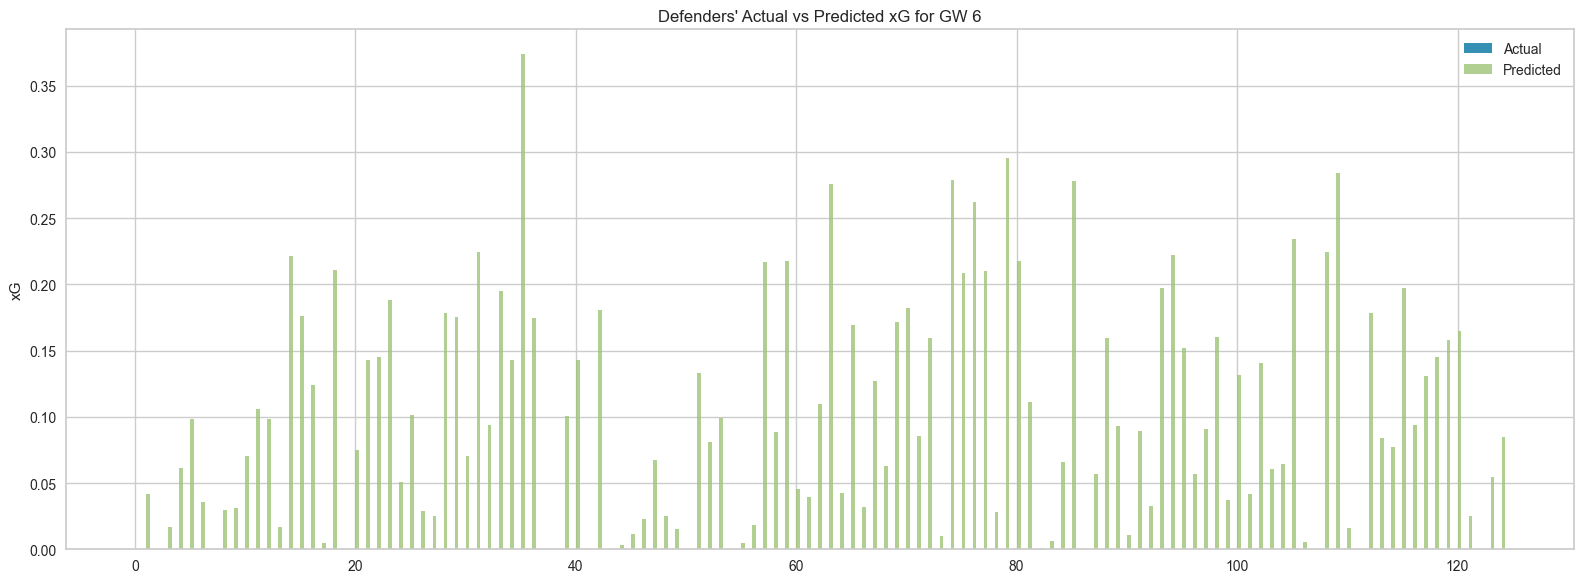

In [423]:
def_xg = data_6_def_xg[['xG']].copy()
data_6_def_xg.drop(columns=['position', 'xG'], inplace=True)

def_xg_preds_6 = predict_model(def_xg_model, data=data_6_def_xg)
def_xg_preds_6 = def_xg_preds_6.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = def_xg['xG']
predicted = pt_def_xg.inverse_transform(def_xg_preds_6[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_6_def
data_6_def['xG_preds'] = predicted



# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Defenders' Actual vs Predicted xG for GW 6")
plt.legend()
plt.tight_layout()
plt.show()


# Goals


In [424]:
xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## DEF


In [425]:
data_36_def_xg = data_36_def[xg_features]
data_37_def_xg = data_37_def[xg_features]
data_38_def_xg = data_38_def[xg_features]

# Load model
def_xg_model = load_model('../def_xg_final_model')
pt_def_xg = joblib.load('../pt_def_xg.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


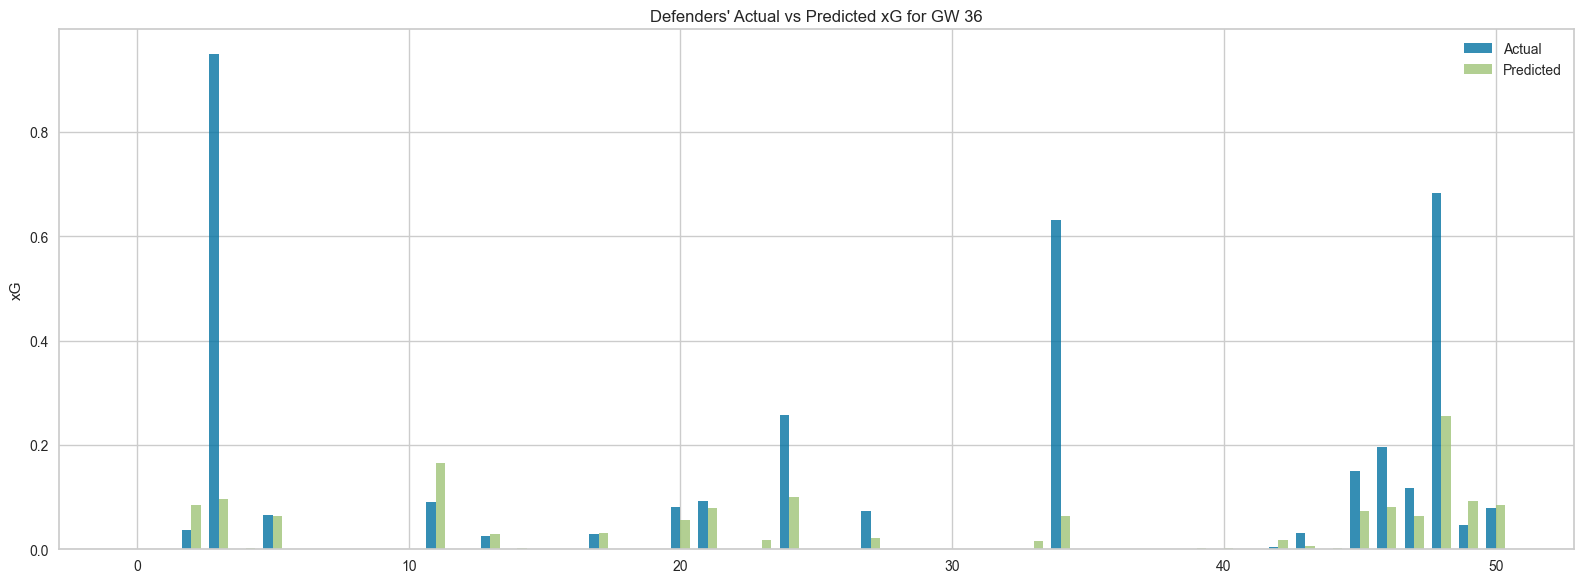

In [426]:
def_xg = data_36_def_xg[['xG']].copy()
data_36_def_xg.drop(columns=['position', 'xG'], inplace=True)

def_xg_preds_36 = predict_model(def_xg_model, data=data_36_def_xg)
def_xg_preds_36 = def_xg_preds_36.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = def_xg['xG']
predicted = pt_def_xg.inverse_transform(def_xg_preds_36[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_36_def
data_36_def['xG_preds'] = predicted



# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Defenders' Actual vs Predicted xG for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


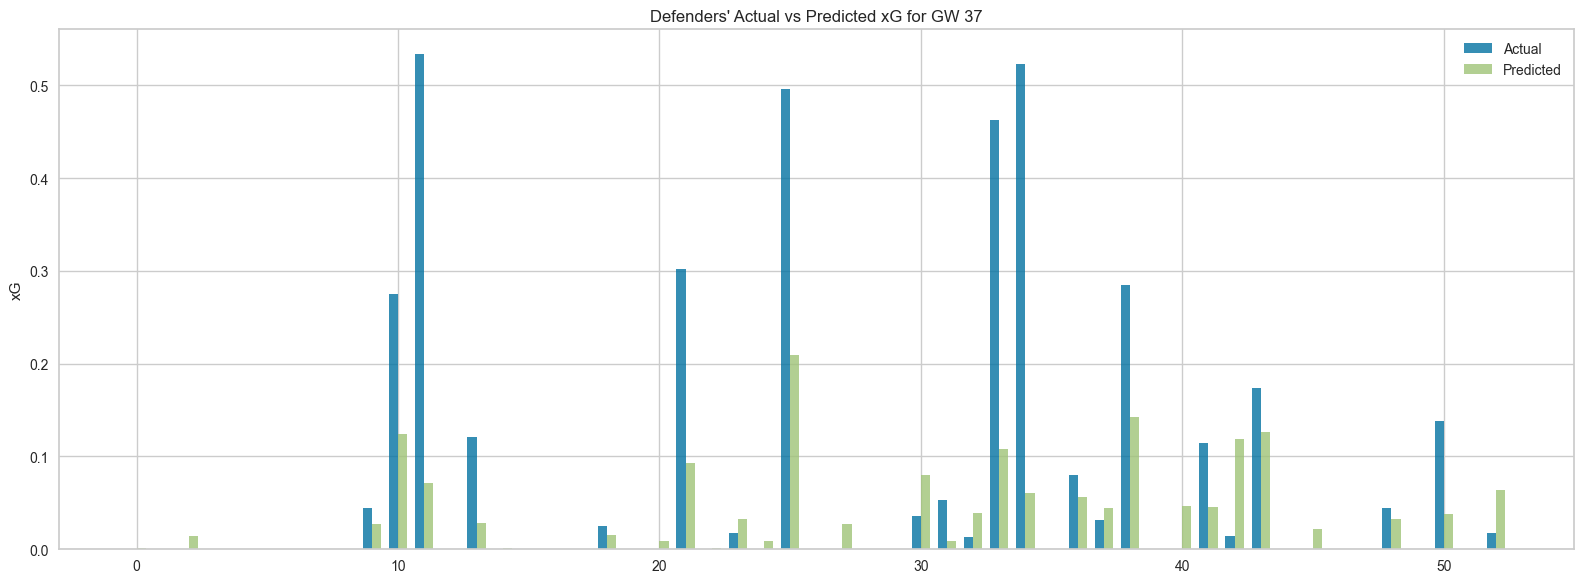

In [427]:
# data_37_def_xg.reset_index(drop=True, inplace=True)
def_xg = data_37_def_xg[['xG']].copy()
data_37_def_xg.drop(columns=['position', 'xG'], inplace=True)

def_xg_preds_37 = predict_model(def_xg_model, data=data_37_def_xg)
def_xg_preds_37 = def_xg_preds_37.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = def_xg['xG']
predicted = pt_def_xg.inverse_transform(def_xg_preds_37[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_37_def
data_37_def['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Defenders' Actual vs Predicted xG for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


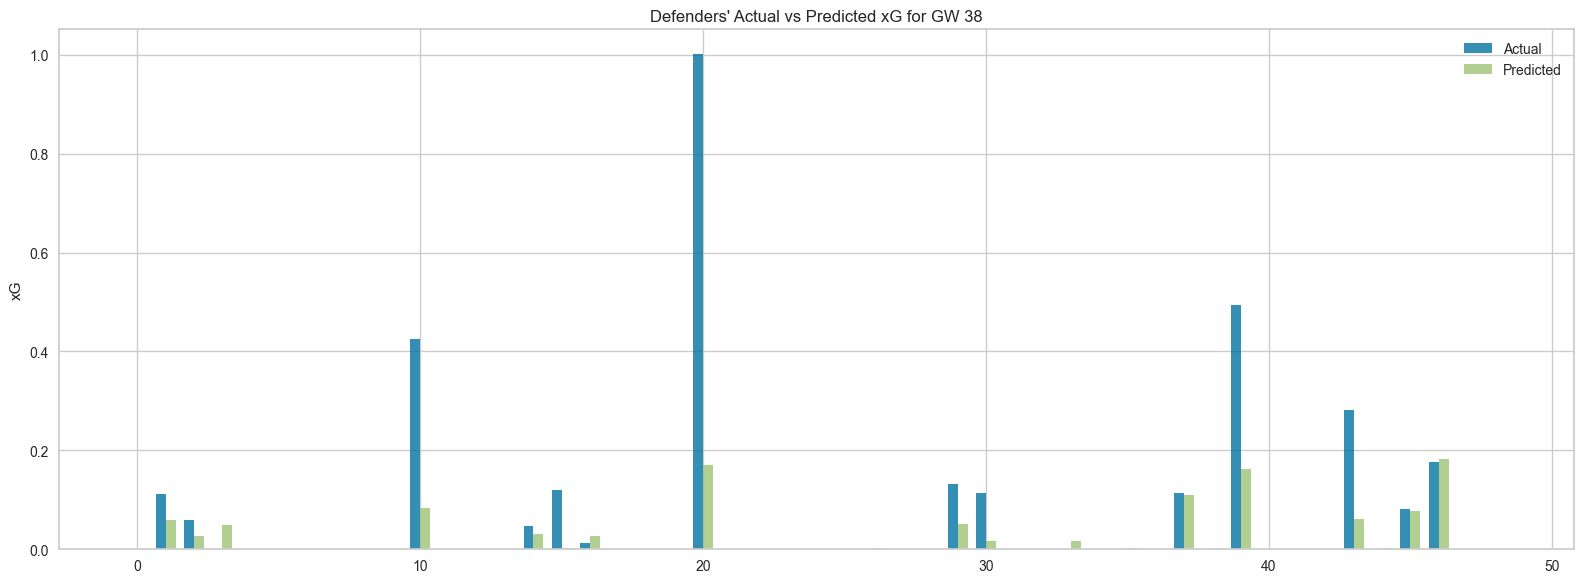

In [428]:
# data_38_def_xg.reset_index(drop=True, inplace=True)
def_xg = data_38_def_xg[['xG']].copy()
data_38_def_xg.drop(columns=['position', 'xG'], inplace=True)

def_xg_preds_38 = predict_model(def_xg_model, data=data_38_def_xg)
def_xg_preds_38 = def_xg_preds_38.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = def_xg['xG']
predicted = pt_def_xg.inverse_transform(def_xg_preds_38[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_38_def
data_38_def['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Defenders' Actual vs Predicted xG for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## MID


In [429]:
data_36_mid_xg = data_36_mid[xg_features]
data_37_mid_xg = data_37_mid[xg_features]
data_38_mid_xg = data_38_mid[xg_features]

# Load model
mid_xg_model = load_model('../mid_xg_final_model')
pt_mid_xg = joblib.load('../pt_mid_xg.pkl')  # Load fitted transformer


Transformation Pipeline and Model Successfully Loaded


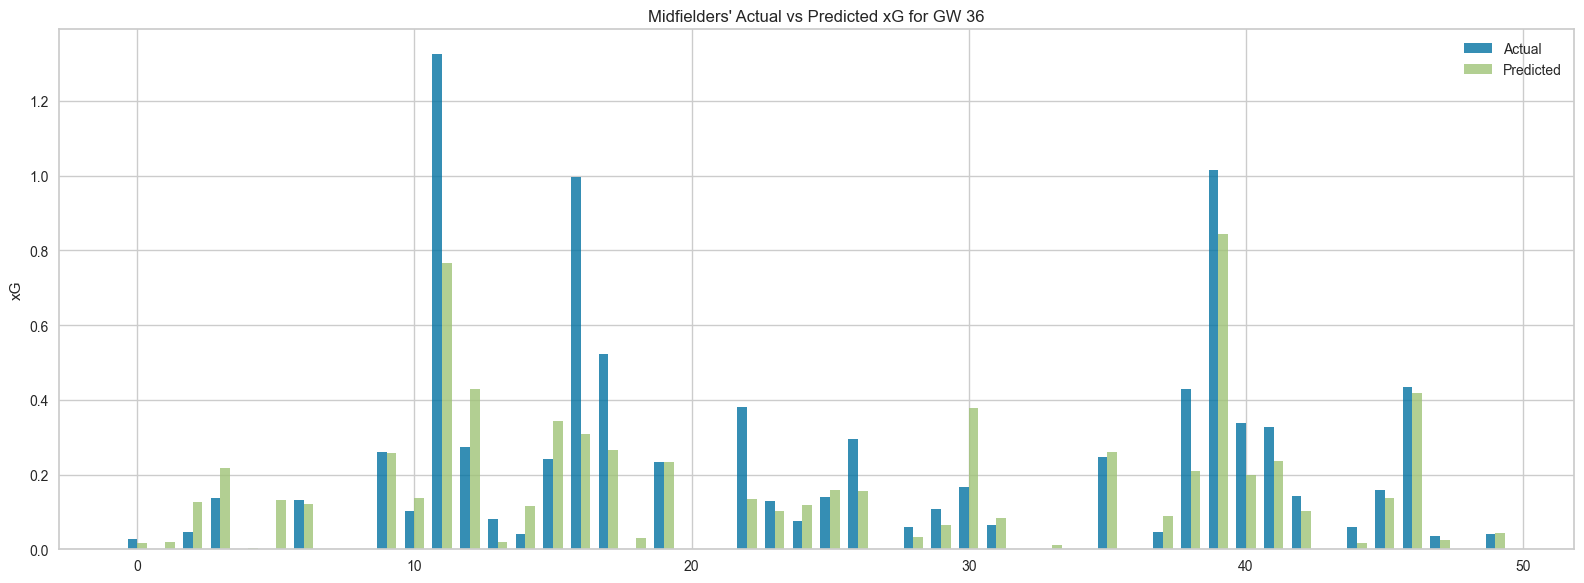

In [430]:
mid_xg = data_36_mid_xg[['xG']].copy()
data_36_mid_xg.drop(columns=['position', 'xG'], inplace=True)

mid_xg_preds_36 = predict_model(mid_xg_model, data=data_36_mid_xg)
mid_xg_preds_36 = mid_xg_preds_36.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = mid_xg['xG']
predicted = pt_mid_xg.inverse_transform(mid_xg_preds_36[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_36_mid
data_36_mid['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Midfielders' Actual vs Predicted xG for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


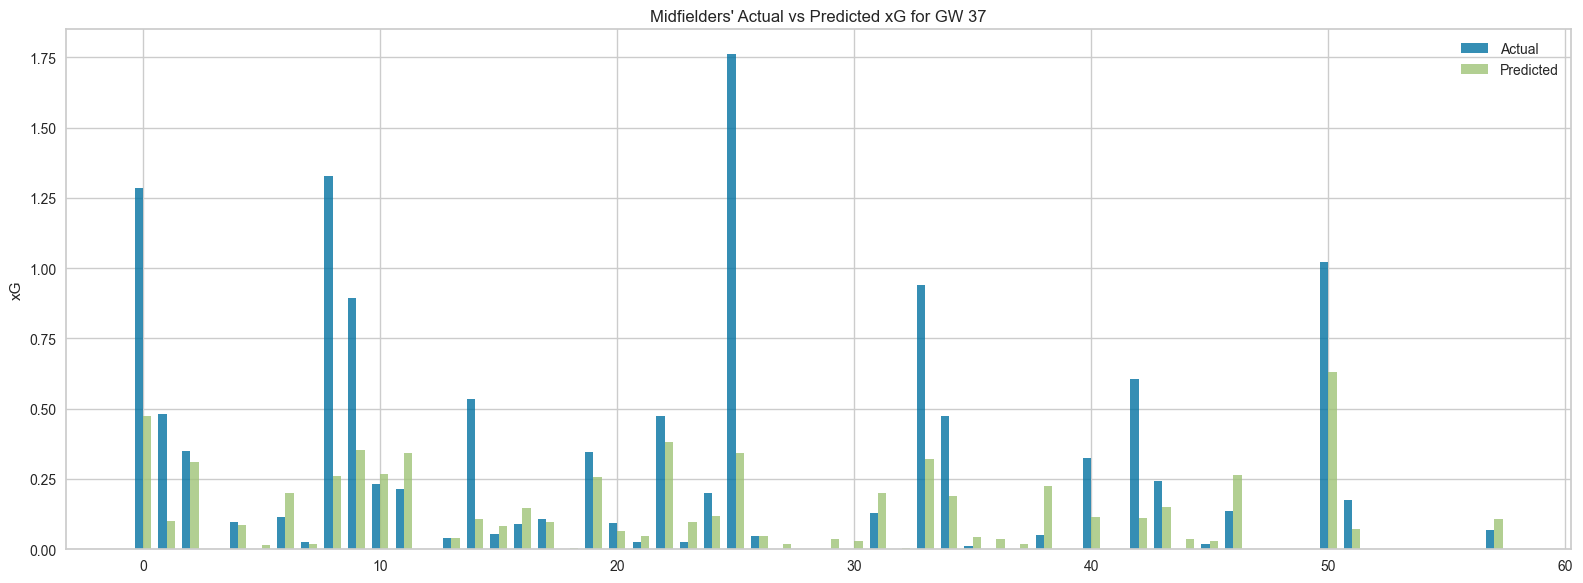

In [431]:
# data_37_mid_xg.reset_index(drop=True, inplace=True)
mid_xg = data_37_mid_xg[['xG']].copy()
data_37_mid_xg.drop(columns=['position', 'xG'], inplace=True)

mid_xg_preds_37 = predict_model(mid_xg_model, data=data_37_mid_xg)
mid_xg_preds_37 = mid_xg_preds_37.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = mid_xg['xG']
predicted = pt_mid_xg.inverse_transform(mid_xg_preds_37[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_37_mid
data_37_mid['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Midfielders' Actual vs Predicted xG for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


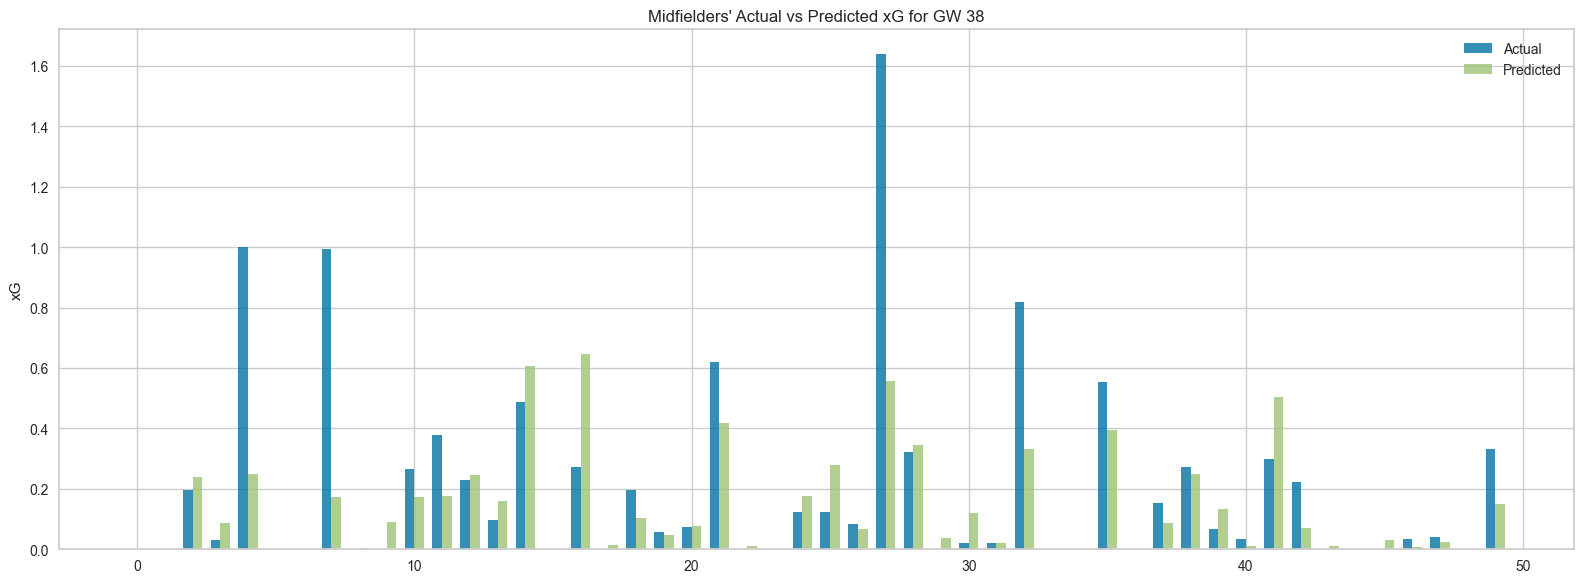

In [432]:
# data_38_mid_xg.reset_index(drop=True, inplace=True)
mid_xg = data_38_mid_xg[['xG']].copy()
data_38_mid_xg.drop(columns=['position', 'xG'], inplace=True)

mid_xg_preds_38 = predict_model(mid_xg_model, data=data_38_mid_xg)
mid_xg_preds_38 = mid_xg_preds_38.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = mid_xg['xG']
predicted = pt_mid_xg.inverse_transform(mid_xg_preds_38[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_38_mid
data_38_mid['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Midfielders' Actual vs Predicted xG for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## FWD


In [433]:
data_36_fwd_xg = data_36_fwd[xg_features]
data_37_fwd_xg = data_37_fwd[xg_features]
data_38_fwd_xg = data_38_fwd[xg_features]

# Load model
fwd_xg_model = load_model('../fwd_xg_final_model')
pt_fwd_xg = joblib.load('../pt_fwd_xg.pkl')  # Load fitted transformer


Transformation Pipeline and Model Successfully Loaded


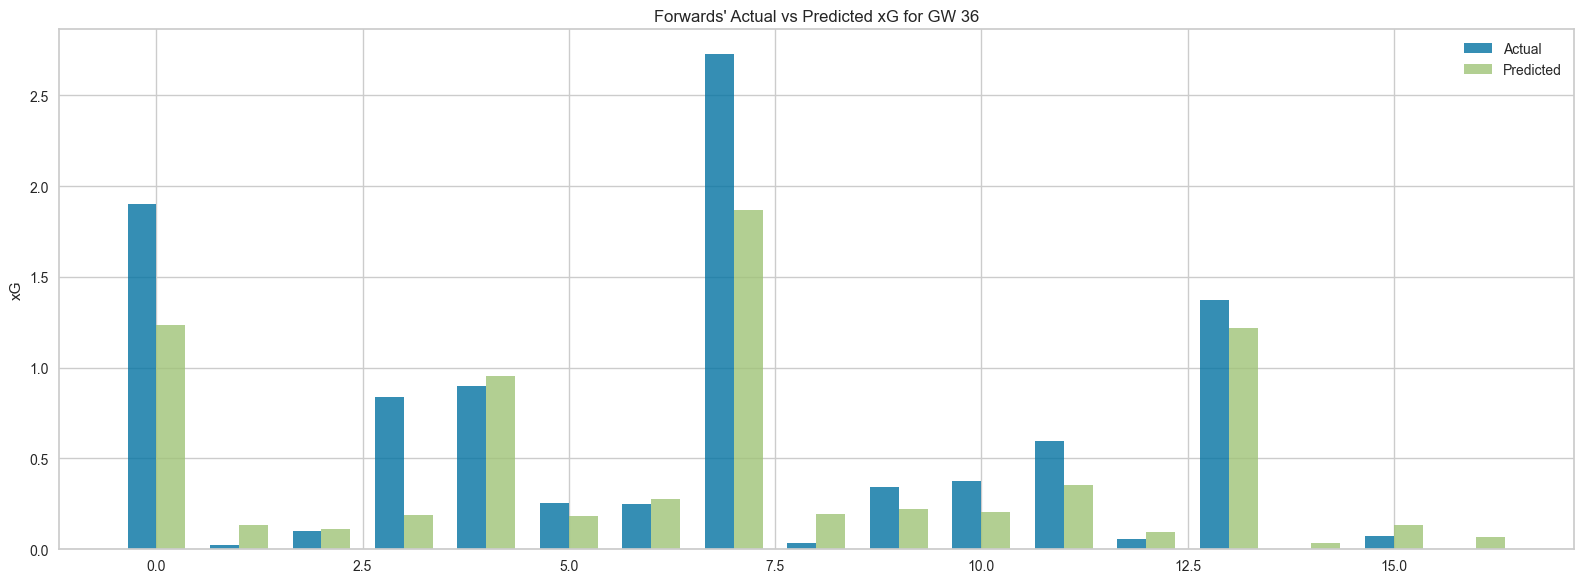

In [434]:
# data_36_fwd_xg.reset_index(drop=True, inplace=True)
fwd_xg = data_36_fwd_xg[['xG']].copy()
data_36_fwd_xg.drop(columns=['position', 'xG'], inplace=True)

fwd_xg_preds_36 = predict_model(fwd_xg_model, data=data_36_fwd_xg)
fwd_xg_preds_36 = fwd_xg_preds_36.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = fwd_xg['xG']
predicted = pt_fwd_xg.inverse_transform(fwd_xg_preds_36[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_36_fwd
data_36_fwd['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Forwards' Actual vs Predicted xG for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


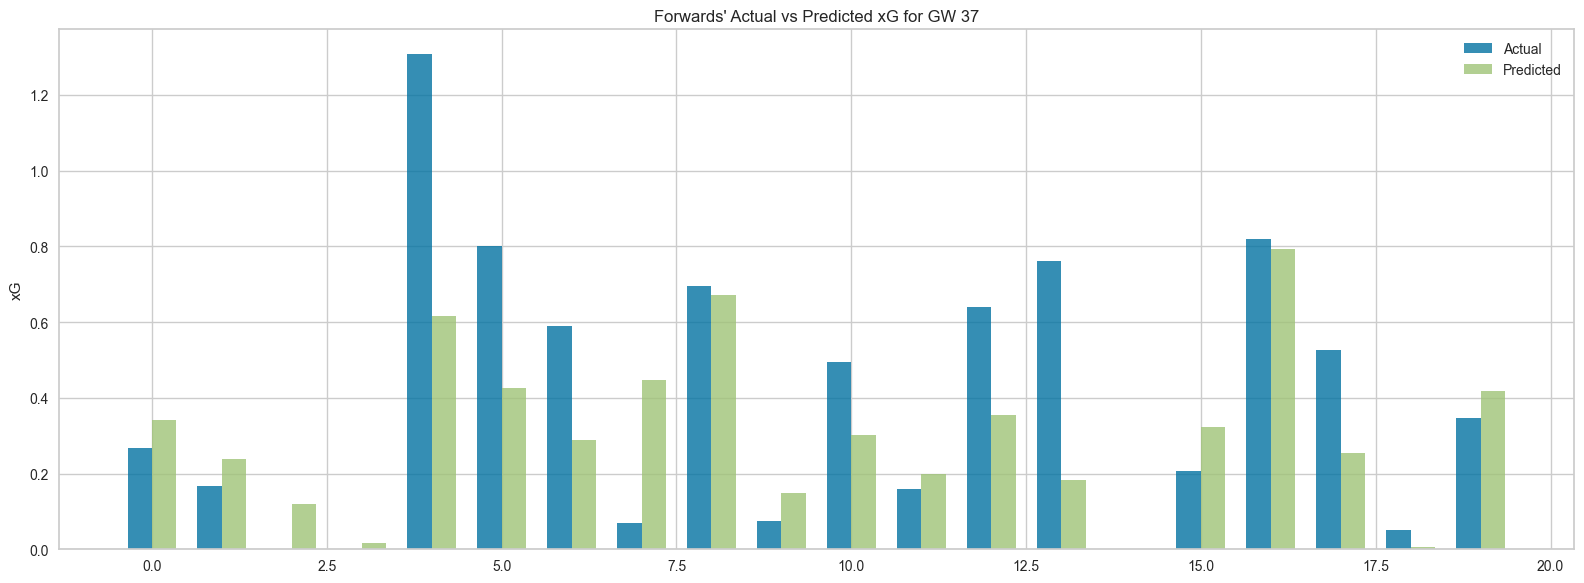

In [435]:
# data_37_fwd_xg.reset_index(drop=True, inplace=True)
fwd_xg = data_37_fwd_xg[['xG']].copy()
data_37_fwd_xg.drop(columns=['position', 'xG'], inplace=True)

fwd_xg_preds_37 = predict_model(fwd_xg_model, data=data_37_fwd_xg)
fwd_xg_preds_37 = fwd_xg_preds_37.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = fwd_xg['xG']
predicted = pt_fwd_xg.inverse_transform(fwd_xg_preds_37[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_37_fwd
data_37_fwd['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Forwards' Actual vs Predicted xG for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


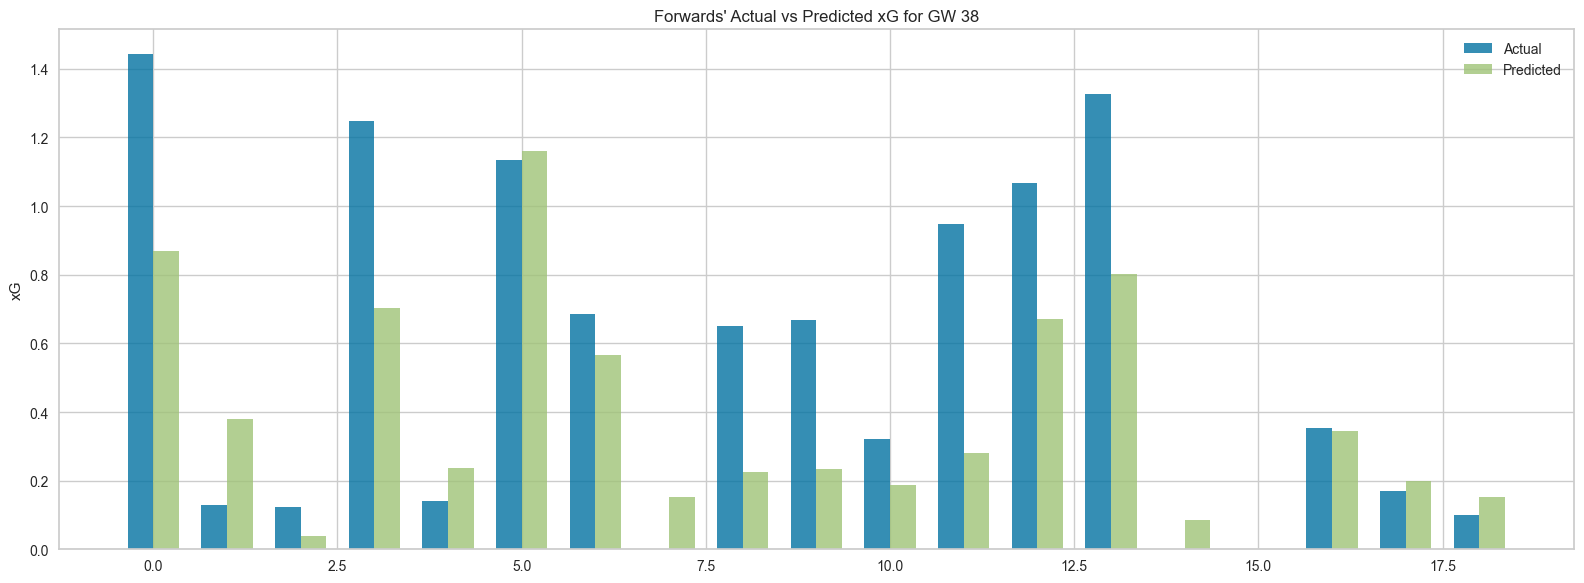

In [436]:
# data_38_fwd_xg.reset_index(drop=True, inplace=True)
fwd_xg = data_38_fwd_xg[['xG']].copy()
data_38_fwd_xg.drop(columns=['position', 'xG'], inplace=True)

fwd_xg_preds_38 = predict_model(fwd_xg_model, data=data_38_fwd_xg)
fwd_xg_preds_38 = fwd_xg_preds_38.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = fwd_xg['xG']
predicted = pt_fwd_xg.inverse_transform(fwd_xg_preds_38[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_38_fwd
data_38_fwd['xG_preds'] = predicted


# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Forwards' Actual vs Predicted xG for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


# Assists


In [437]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## DEF


In [438]:
data_36_def_xa = data_36_def[xa_features]
data_37_def_xa = data_37_def[xa_features]
data_38_def_xa = data_38_def[xa_features]

# Load model
def_xa_model = load_model('../def_xa_final_model')
pt_def_xa = joblib.load('../pt_def_xa.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


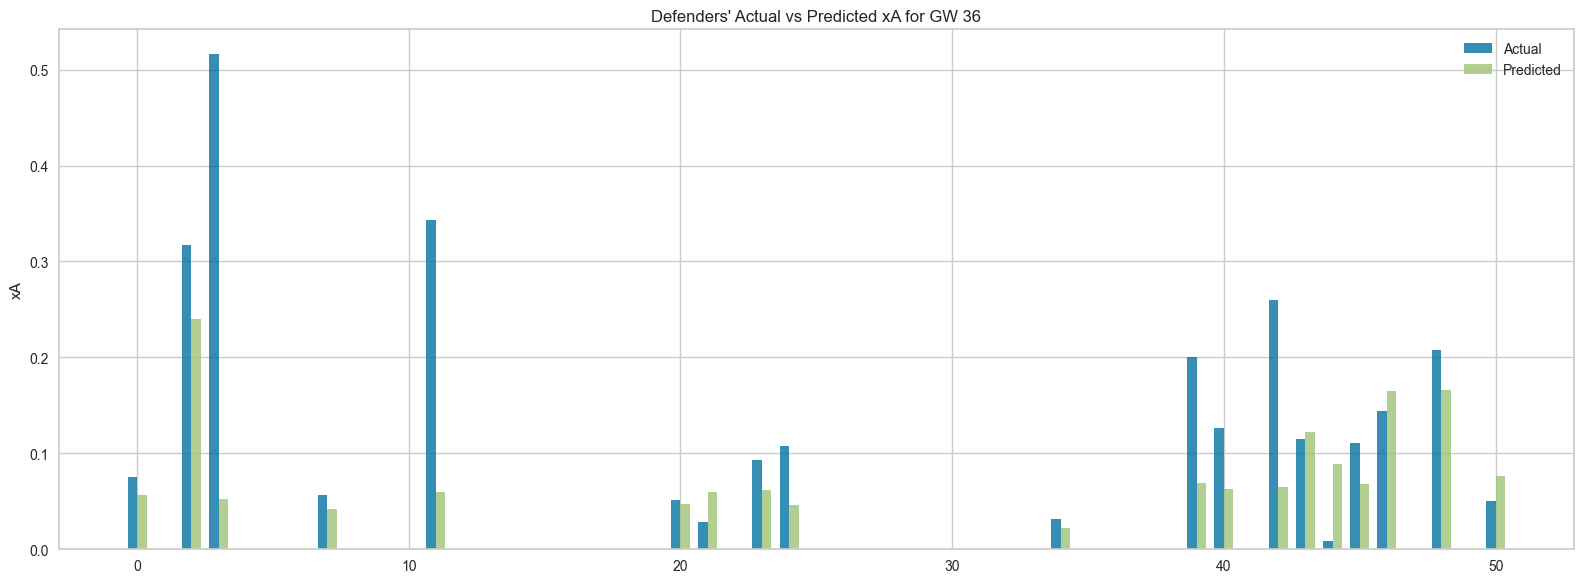

In [439]:
def_xa = data_36_def_xa[['xA']].copy()
data_36_def_xa.drop(columns=['position', 'xA'], inplace=True)

def_xa_preds_36 = predict_model(def_xa_model, data=data_36_def_xa)
def_xa_preds_36 = def_xa_preds_36.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = def_xa['xA']
predicted = pt_def_xa.inverse_transform(def_xa_preds_36[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_36_def
data_36_def['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Defenders' Actual vs Predicted xA for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


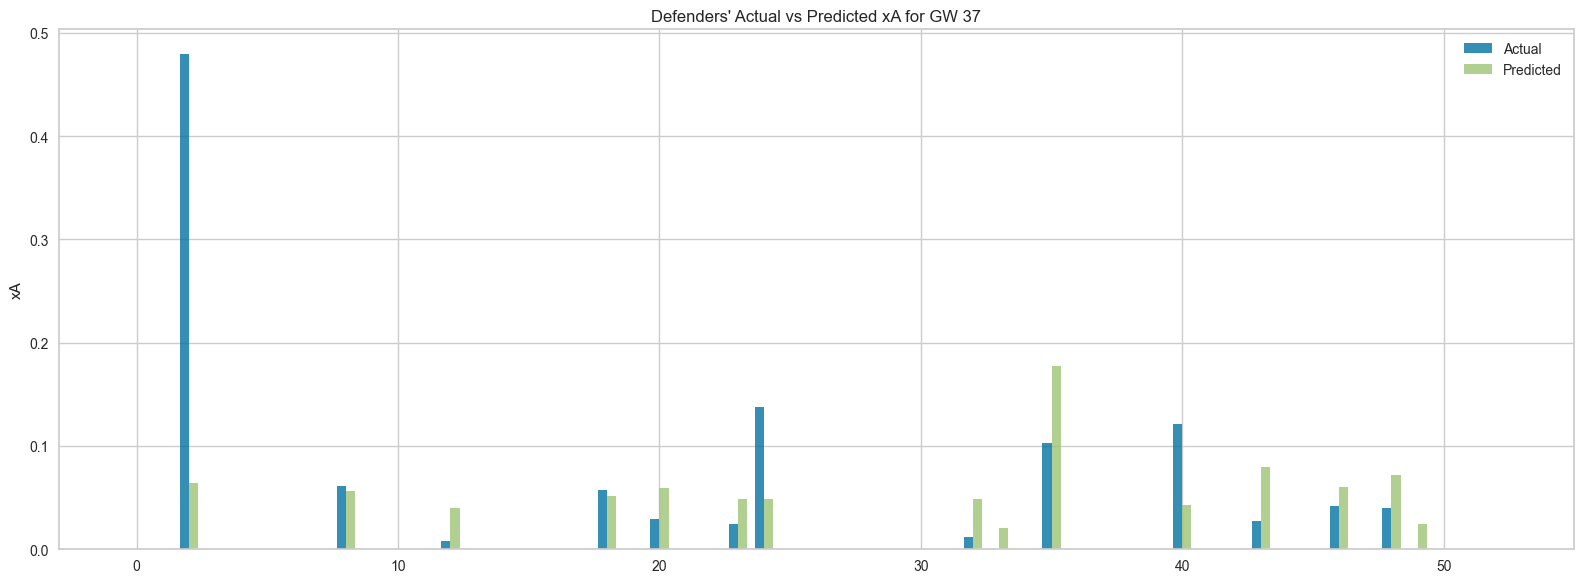

In [440]:
# data_37_def_xa.reset_index(drop=True, inplace=True)
def_xa = data_37_def_xa[['xA']].copy()
data_37_def_xa.drop(columns=['position', 'xA'], inplace=True)

def_xa_preds_37 = predict_model(def_xa_model, data=data_37_def_xa)
def_xa_preds_37 = def_xa_preds_37.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = def_xa['xA']
predicted = pt_def_xa.inverse_transform(def_xa_preds_37[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_37_def
data_37_def['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Defenders' Actual vs Predicted xA for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


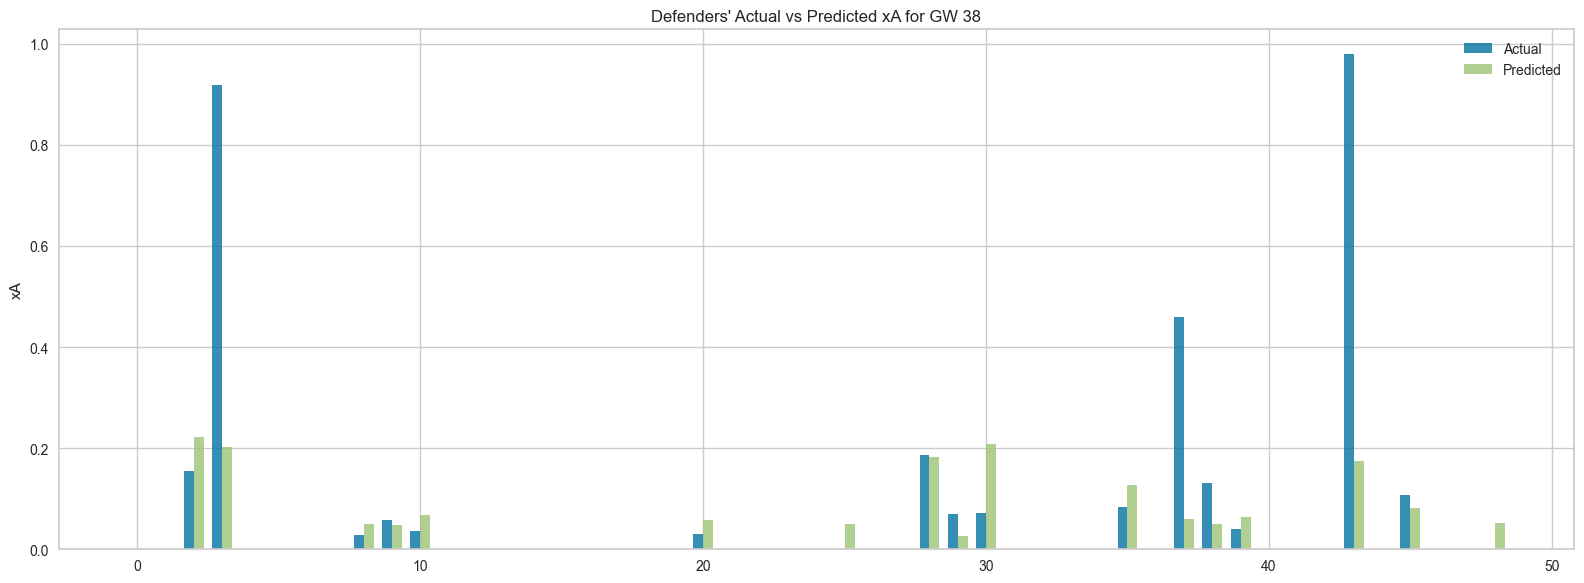

In [441]:
# data_38_def_xa.reset_index(drop=True, inplace=True)
def_xa = data_38_def_xa[['xA']].copy()
data_38_def_xa.drop(columns=['position', 'xA'], inplace=True)

def_xa_preds_38 = predict_model(def_xa_model, data=data_38_def_xa)
def_xa_preds_38 = def_xa_preds_38.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = def_xa['xA']
predicted = pt_def_xa.inverse_transform(def_xa_preds_38[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_38_def
data_38_def['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Defenders' Actual vs Predicted xA for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## MID


In [442]:
data_36_mid_xa = data_36_mid[xa_features]
data_37_mid_xa = data_37_mid[xa_features]
data_38_mid_xa = data_38_mid[xa_features]

# Load model
mid_xa_model = load_model('../mid_xa_final_model')
pt_mid_xa = joblib.load('../pt_mid_xa.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


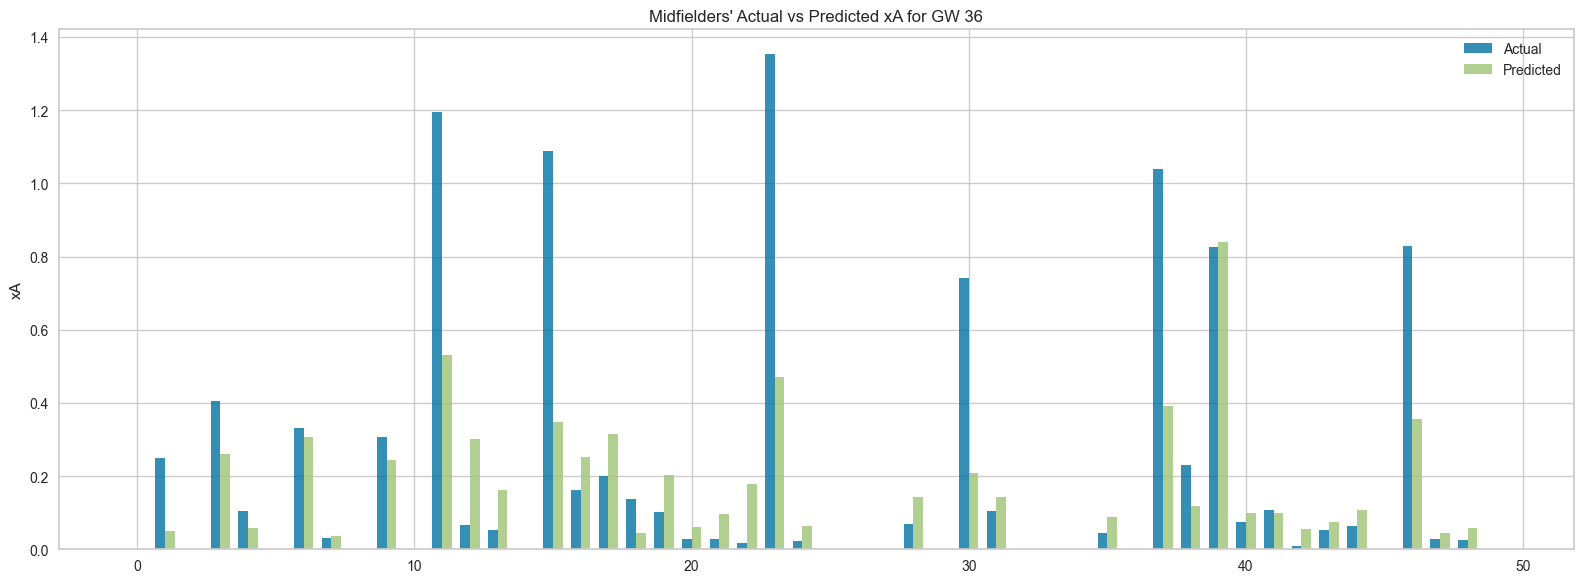

In [443]:
# data_36_mid_xa.reset_index(drop=True, inplace=True)
mid_xa = data_36_mid_xa[['xA']].copy()
data_36_mid_xa.drop(columns=['position', 'xA'], inplace=True)

mid_xa_preds_36 = predict_model(mid_xa_model, data=data_36_mid_xa)
mid_xa_preds_36 = mid_xa_preds_36.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = mid_xa['xA']
predicted = pt_mid_xa.inverse_transform(mid_xa_preds_36[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_36_mid
data_36_mid['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Midfielders' Actual vs Predicted xA for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


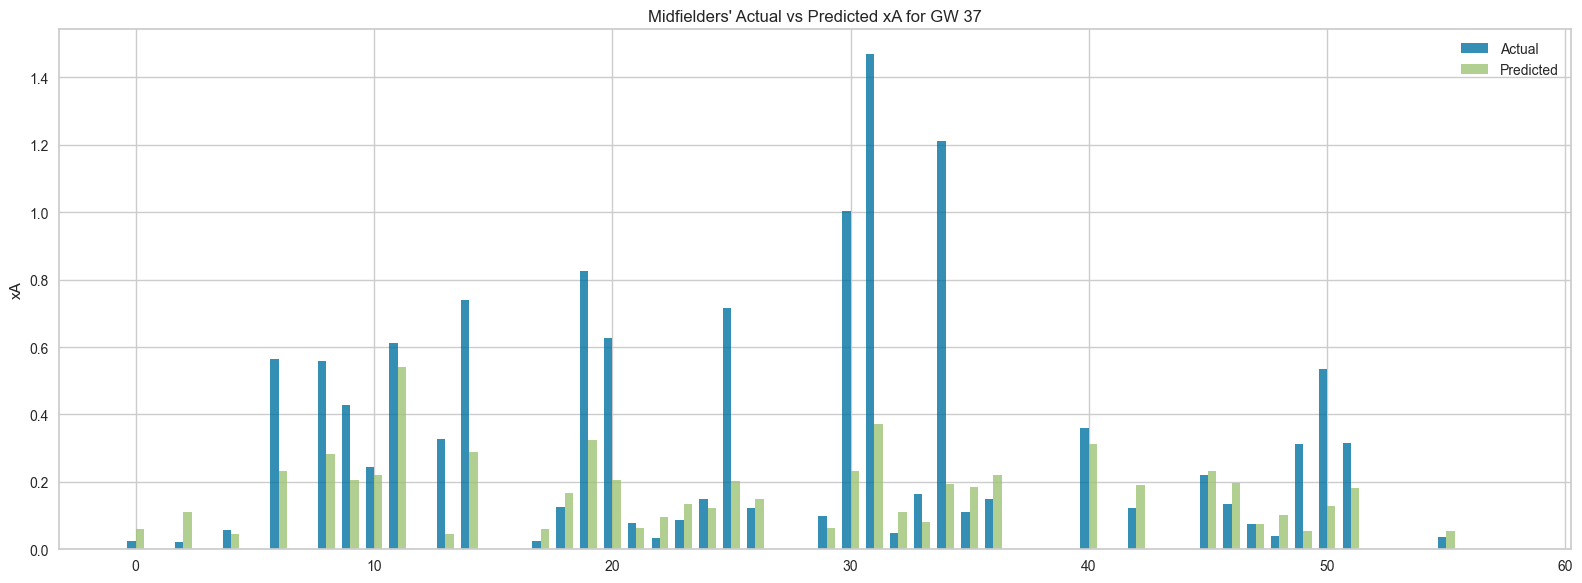

In [444]:
# data_37_mid_xa.reset_index(drop=True, inplace=True)
mid_xa = data_37_mid_xa[['xA']].copy()
data_37_mid_xa.drop(columns=['position', 'xA'], inplace=True)

mid_xa_preds_37 = predict_model(mid_xa_model, data=data_37_mid_xa)
mid_xa_preds_37 = mid_xa_preds_37.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = mid_xa['xA']
predicted = pt_mid_xa.inverse_transform(mid_xa_preds_37[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_37_mid
data_37_mid['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Midfielders' Actual vs Predicted xA for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


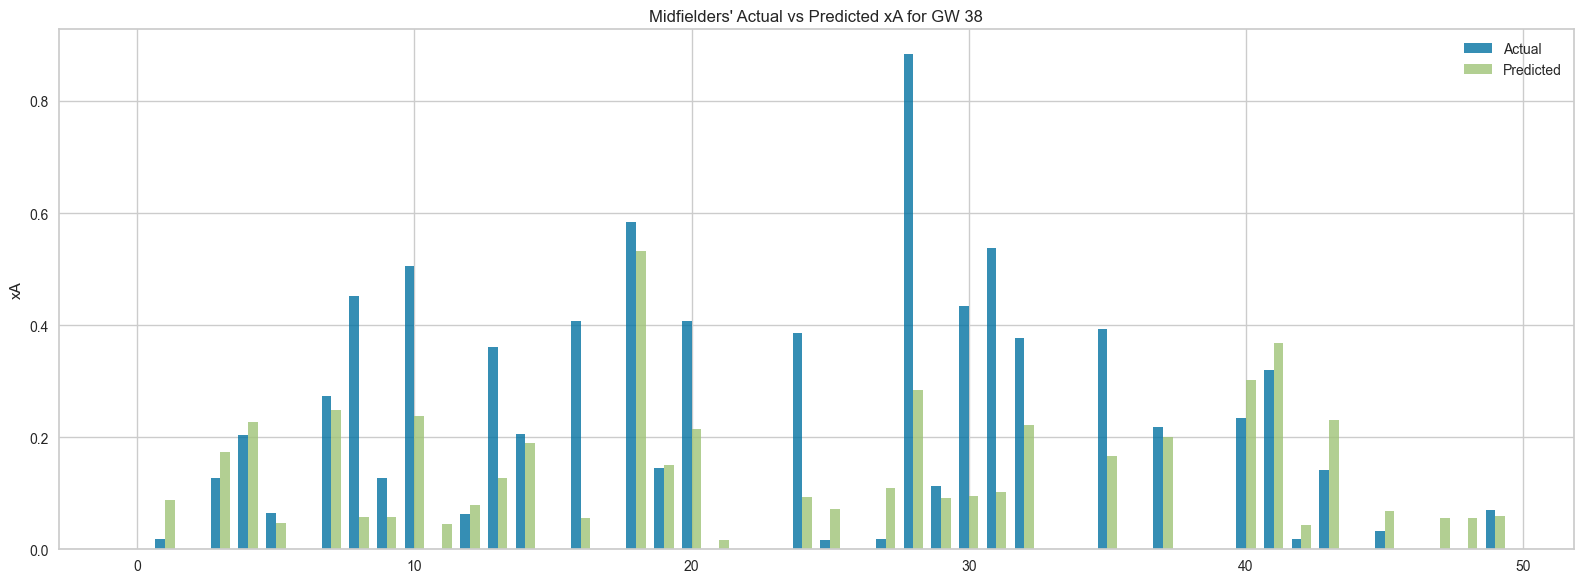

In [445]:
# data_38_mid_xa.reset_index(drop=True, inplace=True)
mid_xa = data_38_mid_xa[['xA']].copy()
data_38_mid_xa.drop(columns=['position', 'xA'], inplace=True)

mid_xa_preds_38 = predict_model(mid_xa_model, data=data_38_mid_xa)
mid_xa_preds_38 = mid_xa_preds_38.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = mid_xa['xA']
predicted = pt_mid_xa.inverse_transform(mid_xa_preds_38[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_38_mid
data_38_mid['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Midfielders' Actual vs Predicted xA for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## FWD


In [446]:
data_36_fwd_xa = data_36_fwd[xa_features]
data_37_fwd_xa = data_37_fwd[xa_features]
data_38_fwd_xa = data_38_fwd[xa_features]

# Load model
fwd_xa_model = load_model('../fwd_xa_final_model')
pt_fwd_xa = joblib.load('../pt_fwd_xa.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


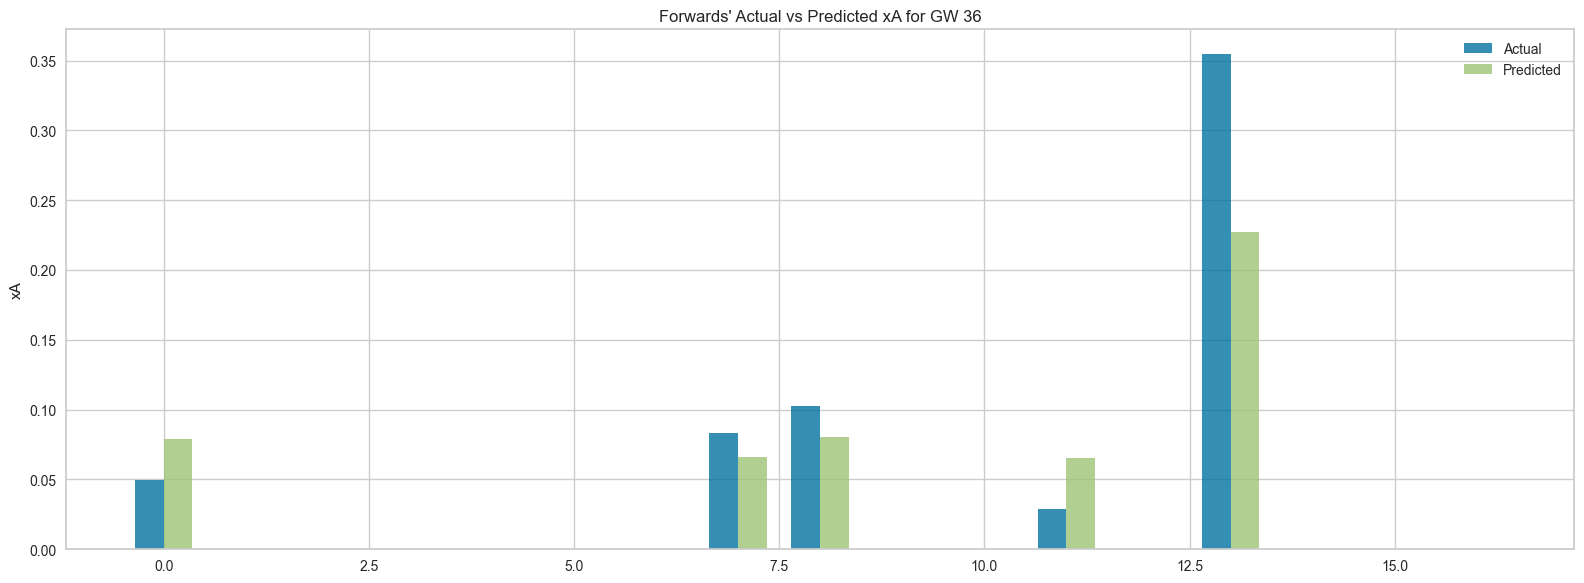

In [447]:
# data_36_fwd_xa.reset_index(drop=True, inplace=True)
fwd_xa = data_36_fwd_xa[['xA']].copy()
data_36_fwd_xa.drop(columns=['position', 'xA'], inplace=True)

fwd_xa_preds_36 = predict_model(fwd_xa_model, data=data_36_fwd_xa)
fwd_xa_preds_36 = fwd_xa_preds_36.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = fwd_xa['xA']
predicted = pt_fwd_xa.inverse_transform(fwd_xa_preds_36[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_36_fwd
data_36_fwd['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Forwards' Actual vs Predicted xA for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


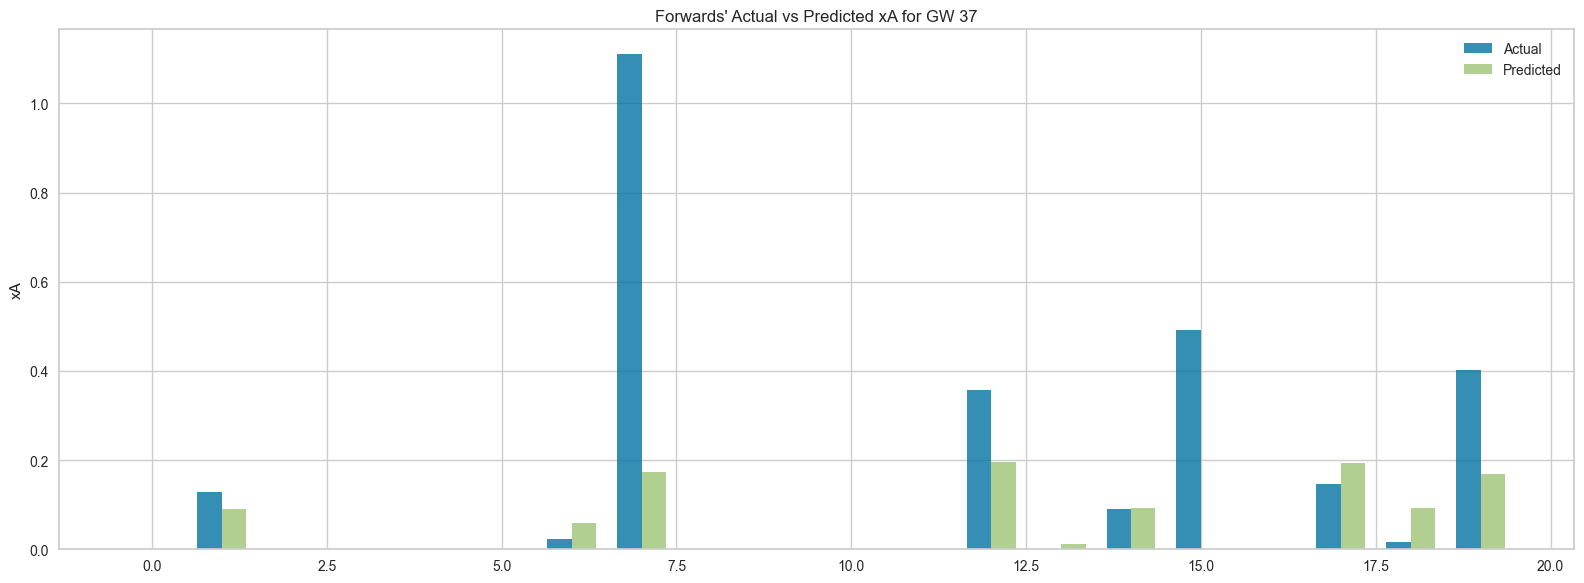

In [448]:
# data_37_fwd_xa.reset_index(drop=True, inplace=True)
fwd_xa = data_37_fwd_xa[['xA']].copy()
data_37_fwd_xa.drop(columns=['position', 'xA'], inplace=True)

fwd_xa_preds_37 = predict_model(fwd_xa_model, data=data_37_fwd_xa)
fwd_xa_preds_37 = fwd_xa_preds_37.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = fwd_xa['xA']
predicted = pt_fwd_xa.inverse_transform(fwd_xa_preds_37[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_37_fwd
data_37_fwd['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Forwards' Actual vs Predicted xA for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


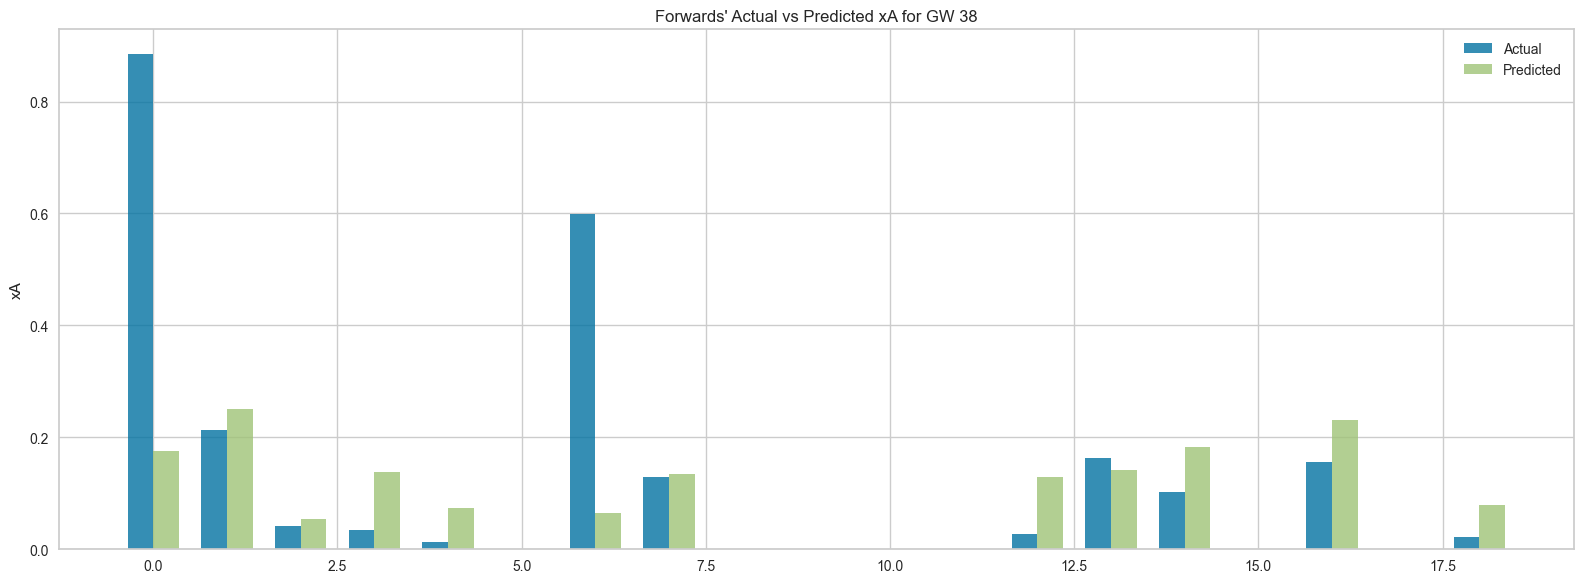

In [449]:
# data_38_fwd_xa.reset_index(drop=True, inplace=True)
fwd_xa = data_38_fwd_xa[['xA']].copy()
data_38_fwd_xa.drop(columns=['position', 'xA'], inplace=True)

fwd_xa_preds_38 = predict_model(fwd_xa_model, data=data_38_fwd_xa)
fwd_xa_preds_38 = fwd_xa_preds_38.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = fwd_xa['xA']
predicted = pt_fwd_xa.inverse_transform(fwd_xa_preds_38[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_38_fwd
data_38_fwd['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Forwards' Actual vs Predicted xA for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


# Saves


In [450]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',


            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


In [451]:
data_36_gk_saves = data_36_gk[saves_features]
data_37_gk_saves = data_37_gk[saves_features]
data_38_gk_saves = data_38_gk[saves_features]

# Load model
gk_saves_model = load_model('../g_saves_final_model')
pt_gk_saves = joblib.load('../pt_gk_saves.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


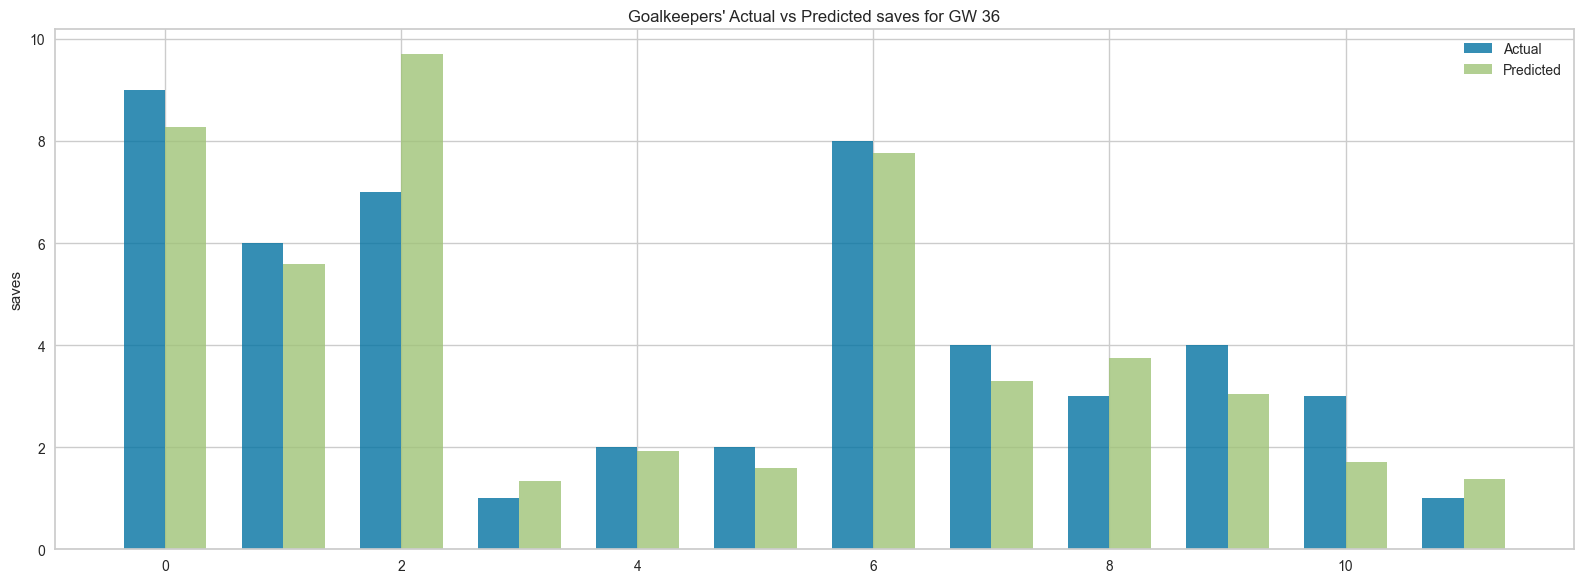

In [452]:
# data_36_gk_saves.reset_index(drop=True, inplace=True)
gk_saves = data_36_gk_saves[['saves']].copy()
data_36_gk_saves.drop(columns=['position', 'saves'], inplace=True)

gk_saves_preds_36 = predict_model(gk_saves_model, data=data_36_gk_saves)
gk_saves_preds_36 = gk_saves_preds_36.rename(columns={'prediction_label': 'saves_preds_trans'})

actual = gk_saves['saves']
predicted = pt_gk_saves.inverse_transform(gk_saves_preds_36[['saves_preds_trans']].rename(columns={'saves_preds_trans': 'saves'}))

# Add predicted to data_36_gk
data_36_gk['saves_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('saves')
plt.title("Goalkeepers' Actual vs Predicted saves for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


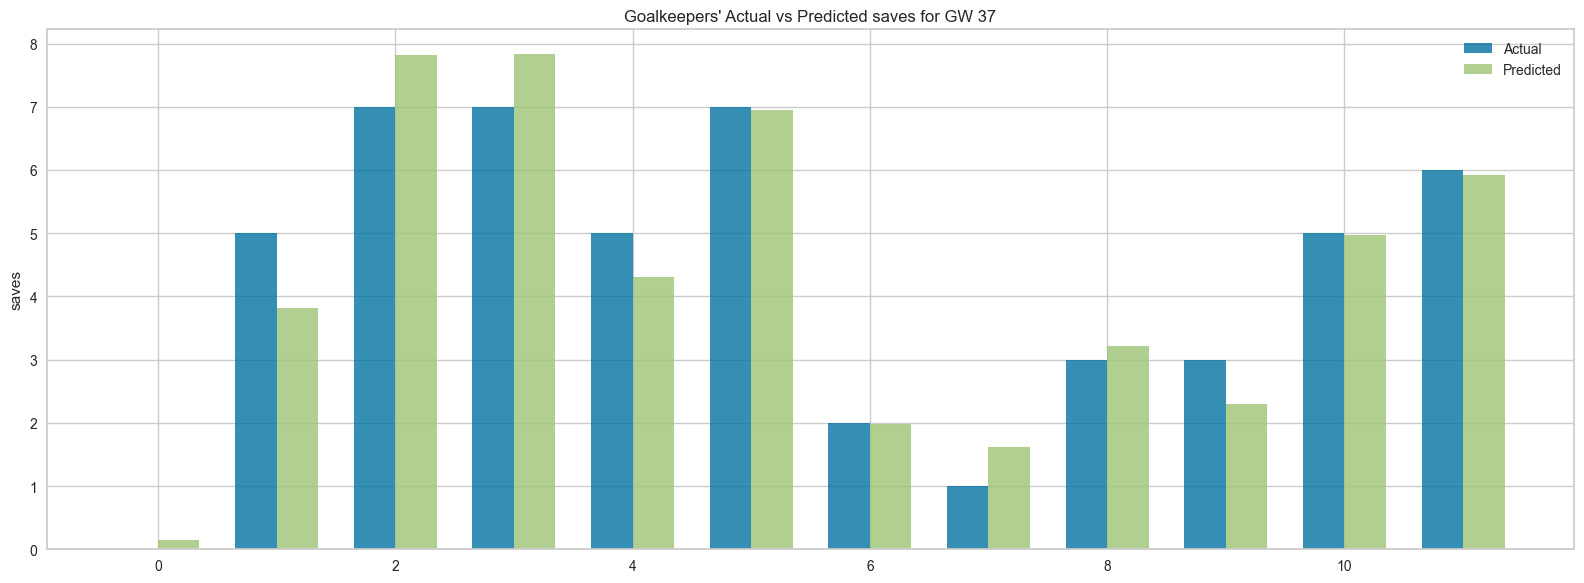

In [453]:
# data_37_gk_saves.reset_index(drop=True, inplace=True)
gk_saves = data_37_gk_saves[['saves']].copy()
data_37_gk_saves.drop(columns=['position', 'saves'], inplace=True)

gk_saves_preds_37 = predict_model(gk_saves_model, data=data_37_gk_saves)
gk_saves_preds_37 = gk_saves_preds_37.rename(columns={'prediction_label': 'saves_preds_trans'})

actual = gk_saves['saves']
predicted = pt_gk_saves.inverse_transform(gk_saves_preds_37[['saves_preds_trans']].rename(columns={'saves_preds_trans': 'saves'}))

# Add predicted to data_37_gk
data_37_gk['saves_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('saves')
plt.title("Goalkeepers' Actual vs Predicted saves for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


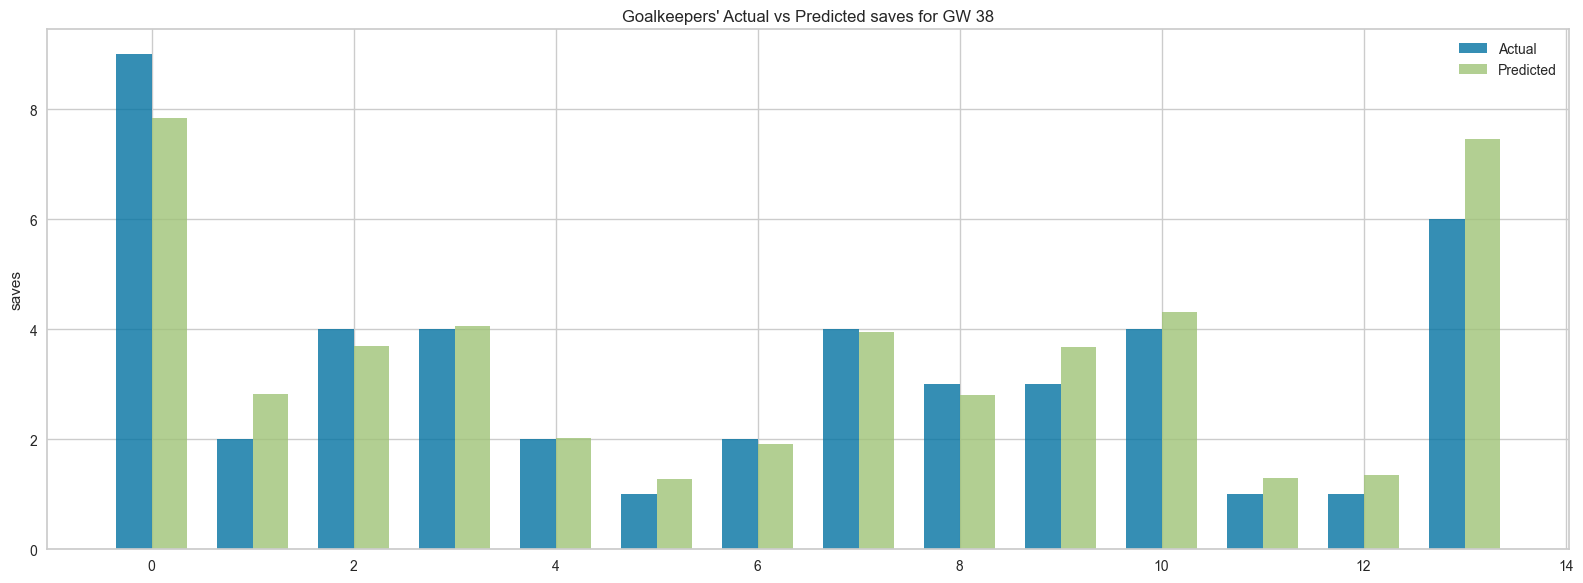

In [454]:
# data_38_gk_saves.reset_index(drop=True, inplace=True)
gk_saves = data_38_gk_saves[['saves']].copy()
data_38_gk_saves.drop(columns=['position', 'saves'], inplace=True)

gk_saves_preds_38 = predict_model(gk_saves_model, data=data_38_gk_saves)
gk_saves_preds_38 = gk_saves_preds_38.rename(columns={'prediction_label': 'saves_preds_trans'})

actual = gk_saves['saves']
predicted = pt_gk_saves.inverse_transform(gk_saves_preds_38[['saves_preds_trans']].rename(columns={'saves_preds_trans': 'saves'}))

# Add predicted to data_38_gk
data_38_gk['saves_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('saves')
plt.title("Goalkeepers' Actual vs Predicted saves for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


<!-- # XGC -->


# XGC


## Prep Data


In [610]:
xgc_data_36 = data_36[(data_36['minutes_5'] >= 60) & (data_36['position'].isin(['GK', 'DEF']))]
xgc_data_37 = data_37[(data_37['minutes_5'] >= 60) & (data_37['position'].isin(['GK', 'DEF']))]
xgc_data_38 = data_38[(data_38['minutes_5'] >= 60) & (data_38['position'].isin(['GK', 'DEF']))]
print(xgc_data_36.shape)


xgc_data_36['gw'] = xgc_data_36['round']
xgc_data_36['team'] = xgc_data_36['player_team']
xgc_data_36['opponent_team'] = xgc_data_36.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)

xgc_data_37['gw'] = xgc_data_37['round']
xgc_data_37['team'] = xgc_data_37['player_team']
xgc_data_37['opponent_team'] = xgc_data_37.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)

xgc_data_38['gw'] = xgc_data_38['round']
xgc_data_38['team'] = xgc_data_38['player_team']
xgc_data_38['opponent_team'] = xgc_data_38.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)

(63, 180)


In [604]:
xgc_data_36

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,percenatge_net_transfers,pts_bps,whh,whd,wha,saves_preds,xgc_preds,xG_preds,xA_preds,gw
44,0,0,12,0,16.6,401,0.05,0.05,0.00,1.47,...,0.317313,0.0,0.402,0.255,0.342,NaN,1.341914,-5.998986e-10,5.654533e-02,36
131,0,0,7,0,1.7,84,0.01,0.01,0.00,3.89,...,-0.745459,0.0,0.785,0.128,0.087,NaN,NaN,-5.998986e-10,-5.693779e-10,36
367,0,0,23,0,90.5,321,0.30,0.32,0.02,1.43,...,-0.741171,2.0,0.365,0.263,0.372,NaN,NaN,8.458284e-02,2.402231e-01,36
398,0,0,26,0,0.0,524,0.00,0.00,0.00,4.13,...,-0.561480,3.0,0.577,0.212,0.212,8.272136,2.197726,NaN,NaN,36
478,0,1,42,1,12.9,307,0.27,1.18,0.91,0.28,...,0.100024,12.0,0.641,0.167,0.192,NaN,NaN,9.695659e-02,5.190851e-02,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7221,0,0,29,1,6.8,194,0.06,0.21,0.15,0.99,...,0.937731,6.0,0.577,0.212,0.212,NaN,NaN,6.297335e-02,-5.693779e-10,36
7260,0,0,38,1,27.0,234,0.12,0.46,0.34,0.35,...,-0.545711,12.0,0.402,0.255,0.342,NaN,NaN,2.560684e-01,1.655112e-01,36
7316,0,0,15,0,0.3,313,0.00,0.08,0.08,1.16,...,-0.919583,1.0,0.641,0.167,0.192,NaN,NaN,9.331804e-02,-5.693779e-10,36
7412,0,0,9,0,0.0,482,0.00,0.00,0.00,1.49,...,0.238011,1.0,0.200,0.226,0.575,1.380561,1.027719,NaN,NaN,36


In [605]:
sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

# max_features = [
#     'minutes_1', 'influence'
# ]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team',
    'fpl_name'
]

team_df_36 = xgc_data_36.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

team_df_37 = xgc_data_37.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

team_df_38 = xgc_data_38.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()


In [606]:

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df_36[f'{col}_3'] = team_df_36.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df_36[f'{col}_5'] = team_df_36.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)

    team_df_37[f'{col}_3'] = team_df_37.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df_37[f'{col}_5'] = team_df_37.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)

    team_df_38[f'{col}_3'] = team_df_38.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df_38[f'{col}_5'] = team_df_38.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)

team_cols_rename = {
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',
    }


team_df_36 = team_df_36.rename(columns=team_cols_rename)
team_df_37 = team_df_37.rename(columns=team_cols_rename)
team_df_38 = team_df_38.rename(columns=team_cols_rename)

In [607]:
opps_cols = ['opponent_team', 'gw', 'fpl_name', 'team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']

opps_cols_rename = {'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        }
opponent_stats_36 = team_df_36[opps_cols].rename(columns=opps_cols_rename)
opponent_stats_37 = team_df_37[opps_cols].rename(columns=opps_cols_rename)
opponent_stats_38 = team_df_38[opps_cols].rename(columns=opps_cols_rename)
opponent_stats_38 = team_df_38[opps_cols].rename(columns=opps_cols_rename)


team_df_36 = team_df_36.merge(opponent_stats_36, on=['opponent_team', 'gw'], how='left')
team_df_37 = team_df_37.merge(opponent_stats_37, on=['opponent_team', 'gw'], how='left')
team_df_38 = team_df_38.merge(opponent_stats_38, on=['opponent_team', 'gw'], how='left')


final_df_36 = xgc_data_36.merge(team_df_36, on=['team', 'gw'], how='left')
final_df_37 = xgc_data_37.merge(team_df_37, on=['team', 'gw'], how='left')
final_df_38 = xgc_data_38.merge(team_df_38, on=['team', 'gw'], how='left')

In [608]:
final_cols = ['expected_goals_conceded', 'creativity','ict_index', 'influence','selected',  'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home',
        'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'pts_bps', 'whh', 'whd', 'wha', 'team_creativity', 'team_influence',
        'team_threat', 'team_expected_goals', 'team_expected_assists', 'team_expected_goal_involvements', 'team_expected_goals_conceded', 'team_goals_conceded', 'team_goals_scored',
         'team_shots', 'team_key_passes', 'team_npg', 'team_npxG', 'team_value', 'team_ict_index', 'team_selected','team_transfers_in', 'team_transfers_out', 'team_whh', 'team_whd',
         'team_wha',

        'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG',
        'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha',

        'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
        'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
        'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1',  'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',
        'xP_1',

        'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
        'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
        'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3',  'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',
        'xP_3',

        'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
        'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
        'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5',  'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',
        'xP_5',
        ]


## Predict


In [620]:
xgc_scaler = joblib.load('../xgc_scaler_xgc.pkl')  # Load fitted scaler
# Load model
xgc_model = load_model('../xgc_final_model')

Transformation Pipeline and Model Successfully Loaded


### GK


In [621]:
final_df_gk_36 = final_df_36[final_df_36['position'] == 'GK'].reset_index(drop=True)
xgc_gk_36 = final_df_gk_36[final_cols].copy()
# xgc_gk_36 = xgc_gk_36.dropna().reset_index(drop=True)

final_df_gk_37 = final_df_37[final_df_37['position'] == 'GK'].reset_index(drop=True)
xgc_gk_37 = final_df_gk_37[final_cols].copy()
# xgc_gk_37 = xgc_gk_37.dropna().reset_index(drop=True)

final_df_gk_38 = final_df_38[final_df_38['position'] == 'GK'].reset_index(drop=True)
xgc_gk_38 = final_df_gk_38[final_cols].copy()
# xgc_gk_38 = xgc_gk_38.dropna().reset_index(drop=True)



xgc_36_scaled = pd.DataFrame(xgc_scaler.transform(xgc_gk_36.drop(columns=['expected_goals_conceded'])),
                                columns=xgc_gk_36.drop(columns=['expected_goals_conceded']).columns)
xgc_scaled_36 = pd.concat([xgc_36_scaled, xgc_gk_36[['expected_goals_conceded']]], axis=1)

xgc_37_scaled = pd.DataFrame(xgc_scaler.transform(xgc_gk_37.drop(columns=['expected_goals_conceded'])),
                                columns=xgc_gk_37.drop(columns=['expected_goals_conceded']).columns)
xgc_scaled_37 = pd.concat([xgc_37_scaled, xgc_gk_37[['expected_goals_conceded']]], axis=1)

xgc_38_scaled = pd.DataFrame(xgc_scaler.transform(xgc_gk_38.drop(columns=['expected_goals_conceded'])),
                                columns=xgc_gk_38.drop(columns=['expected_goals_conceded']).columns)
xgc_scaled_38 = pd.concat([xgc_38_scaled, xgc_gk_38[['expected_goals_conceded']]], axis=1)


xgc_gk_tar_36 = xgc_scaled_36['expected_goals_conceded'].copy()
xgc_gk_tar_37 = xgc_scaled_37['expected_goals_conceded'].copy()
xgc_gk_tar_38 = xgc_scaled_38['expected_goals_conceded'].copy()

xgc_model_data_36 = xgc_scaled_36.copy()
xgc_model_data_36.drop(columns=['expected_goals_conceded'], inplace=True)

xgc_model_data_37 = xgc_scaled_37.copy()
xgc_model_data_37.drop(columns=['expected_goals_conceded'], inplace=True)

xgc_model_data_38 = xgc_scaled_38.copy()
xgc_model_data_38.drop(columns=['expected_goals_conceded'], inplace=True)


xgc_gk_preds_36 = predict_model(xgc_model, data=xgc_model_data_36)
xgc_gk_preds_36.rename(columns={'prediction_label': 'xgc_preds'}, inplace=True)
xgc_gk_preds_36['xgc_preds'] = xgc_gk_preds_36['xgc_preds'].apply(lambda x: np.expm1(x))

xgc_gk_preds_37 = predict_model(xgc_model, data=xgc_model_data_37)
xgc_gk_preds_37.rename(columns={'prediction_label': 'xgc_preds'}, inplace=True)
xgc_gk_preds_37['xgc_preds'] = xgc_gk_preds_37['xgc_preds'].apply(lambda x: np.expm1(x))

xgc_gk_preds_38 = predict_model(xgc_model, data=xgc_model_data_38)
xgc_gk_preds_38.rename(columns={'prediction_label': 'xgc_preds'}, inplace=True)
xgc_gk_preds_38['xgc_preds'] = xgc_gk_preds_38['xgc_preds'].apply(lambda x: np.expm1(x))


# Add predicted to data_36_def
data_36_gk['xgc_preds'] = xgc_gk_preds_36['xgc_preds'].values
data_37_gk['xgc_preds'] = xgc_gk_preds_37['xgc_preds'].values
data_38_gk['xgc_preds'] = xgc_gk_preds_38['xgc_preds'].values

# Add fpl_name to data_36_def
data_36_gk['fpl_name'] = final_df_gk_36['fpl_name'].values
data_37_gk['fpl_name'] = final_df_gk_37['fpl_name'].values
data_38_gk['fpl_name'] = final_df_gk_38['fpl_name'].values



#### Plots


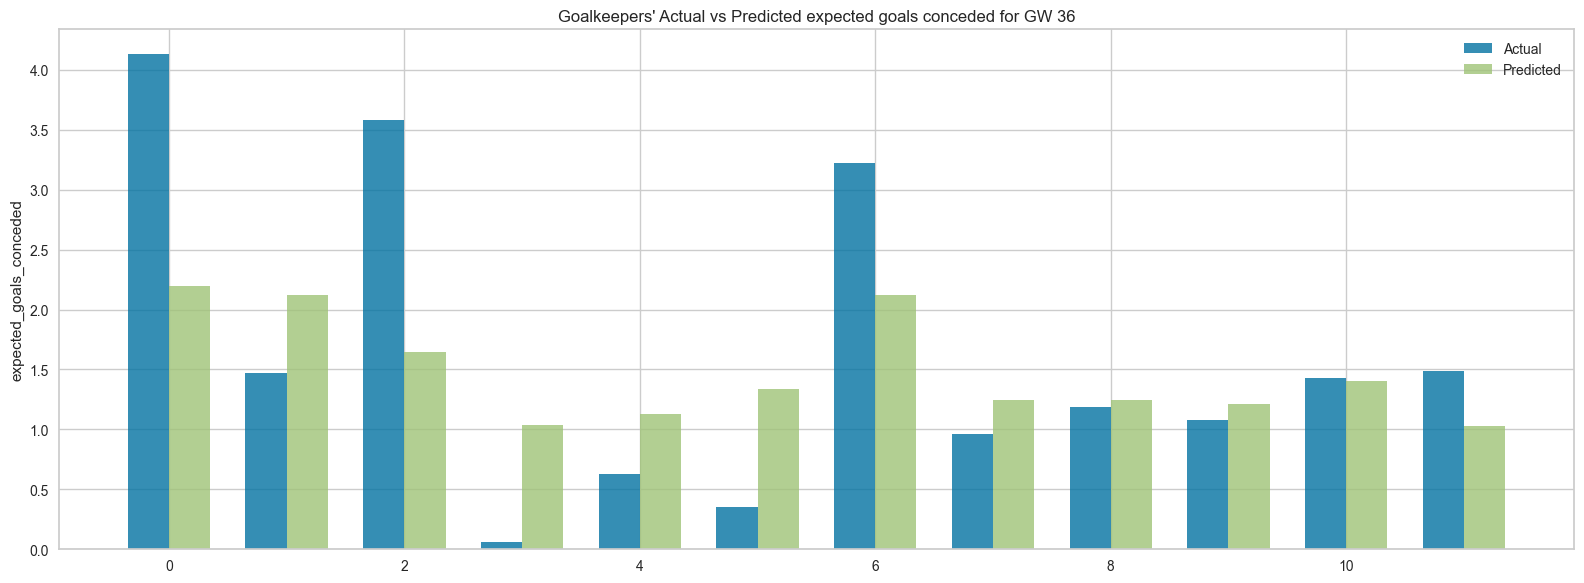

In [622]:
# Bar plot side-by-side
x = np.arange(len(xgc_gk_tar_36))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, xgc_gk_tar_36, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, xgc_gk_preds_36['xgc_preds'].tolist(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Goalkeepers' Actual vs Predicted expected goals conceded for GW 36")
plt.legend()
plt.tight_layout()
plt.show()

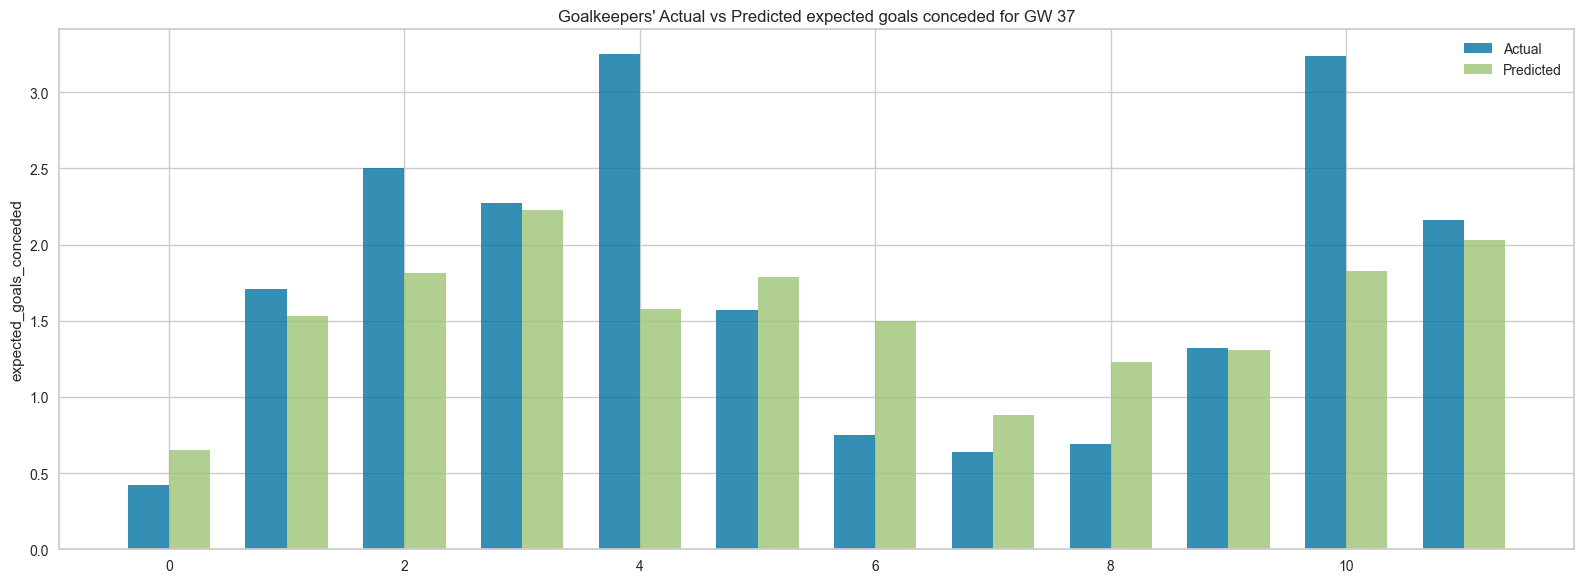

In [623]:
# Bar plot side-by-side
x = np.arange(len(xgc_gk_tar_37))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, xgc_gk_tar_37, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, xgc_gk_preds_37['xgc_preds'].tolist(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Goalkeepers' Actual vs Predicted expected goals conceded for GW 37")
plt.legend()
plt.tight_layout()
plt.show()

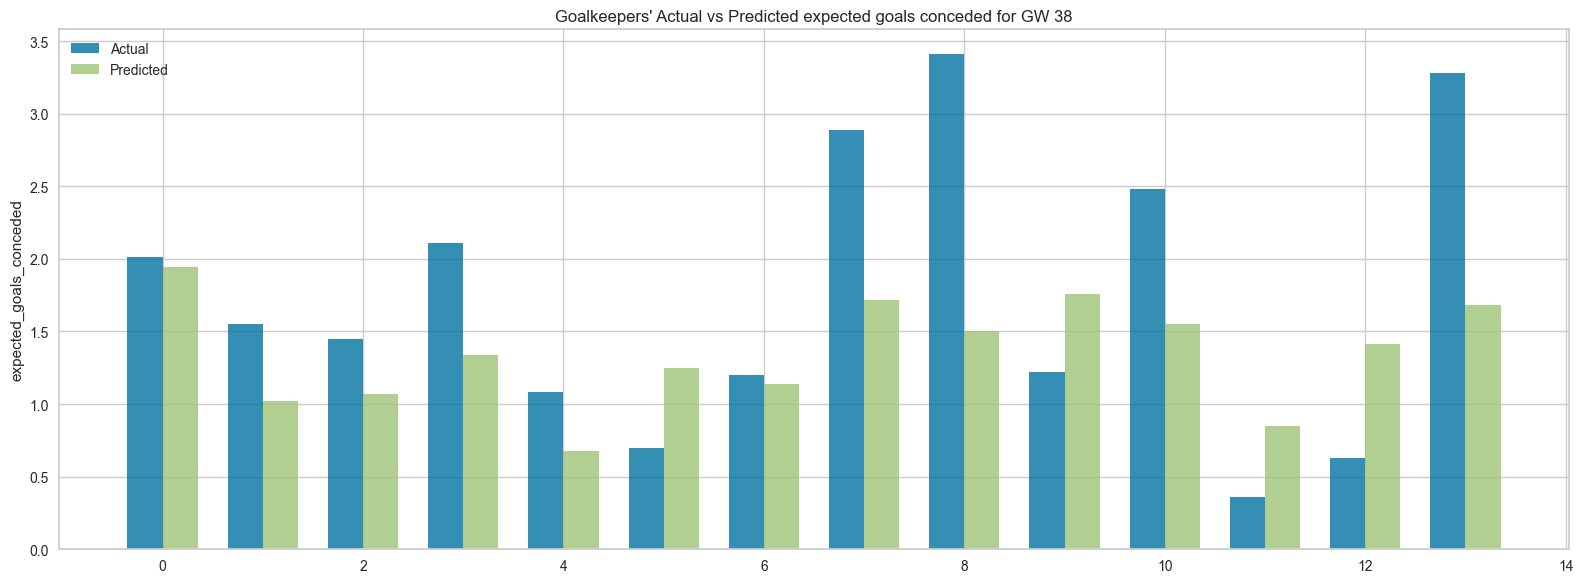

In [624]:
# Bar plot side-by-side
x = np.arange(len(xgc_gk_tar_38))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, xgc_gk_tar_38, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, xgc_gk_preds_38['xgc_preds'].tolist(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Goalkeepers' Actual vs Predicted expected goals conceded for GW 38")
plt.legend()
plt.tight_layout()
plt.show()

### DEF


In [625]:
final_df_def_36 = final_df_36[final_df_36['position'] == 'DEF'].reset_index(drop=True)
xgc_def_36 = final_df_def_36[final_cols].copy()
# xgc_def_36 = xgc_def_36.dropna().reset_index(drop=True)

final_df_def_37 = final_df_37[final_df_37['position'] == 'DEF'].reset_index(drop=True)
xgc_def_37 = final_df_def_37[final_cols].copy()
# xgc_def_37 = xgc_def_37.dropna().reset_index(drop=True)

final_df_def_38 = final_df_38[final_df_38['position'] == 'DEF'].reset_index(drop=True)
xgc_def_38 = final_df_def_38[final_cols].copy()
# xgc_def_38 = xgc_def_38.dropna().reset_index(drop=True)



xgc_36_scaled = pd.DataFrame(xgc_scaler.transform(xgc_def_36.drop(columns=['expected_goals_conceded'])),
                                columns=xgc_def_36.drop(columns=['expected_goals_conceded']).columns)
xgc_scaled_36 = pd.concat([xgc_36_scaled, xgc_def_36[['expected_goals_conceded']]], axis=1)

xgc_37_scaled = pd.DataFrame(xgc_scaler.transform(xgc_def_37.drop(columns=['expected_goals_conceded'])),
                                columns=xgc_def_37.drop(columns=['expected_goals_conceded']).columns)
xgc_scaled_37 = pd.concat([xgc_37_scaled, xgc_def_37[['expected_goals_conceded']]], axis=1)

xgc_38_scaled = pd.DataFrame(xgc_scaler.transform(xgc_def_38.drop(columns=['expected_goals_conceded'])),
                                columns=xgc_def_38.drop(columns=['expected_goals_conceded']).columns)
xgc_scaled_38 = pd.concat([xgc_38_scaled, xgc_def_38[['expected_goals_conceded']]], axis=1)


xgc_def_tar_36 = xgc_scaled_36['expected_goals_conceded'].copy()
xgc_def_tar_37 = xgc_scaled_37['expected_goals_conceded'].copy()
xgc_def_tar_38 = xgc_scaled_38['expected_goals_conceded'].copy()

xgc_model_data_36 = xgc_scaled_36.copy()
xgc_model_data_36.drop(columns=['expected_goals_conceded'], inplace=True)

xgc_model_data_37 = xgc_scaled_37.copy()
xgc_model_data_37.drop(columns=['expected_goals_conceded'], inplace=True)

xgc_model_data_38 = xgc_scaled_38.copy()
xgc_model_data_38.drop(columns=['expected_goals_conceded'], inplace=True)


xgc_def_preds_36 = predict_model(xgc_model, data=xgc_model_data_36)
xgc_def_preds_36.rename(columns={'prediction_label': 'xgc_preds'}, inplace=True)
xgc_def_preds_36['xgc_preds'] = xgc_def_preds_36['xgc_preds'].apply(lambda x: np.expm1(x))

xgc_def_preds_37 = predict_model(xgc_model, data=xgc_model_data_37)
xgc_def_preds_37.rename(columns={'prediction_label': 'xgc_preds'}, inplace=True)
xgc_def_preds_37['xgc_preds'] = xgc_def_preds_37['xgc_preds'].apply(lambda x: np.expm1(x))

xgc_def_preds_38 = predict_model(xgc_model, data=xgc_model_data_38)
xgc_def_preds_38.rename(columns={'prediction_label': 'xgc_preds'}, inplace=True)
xgc_def_preds_38['xgc_preds'] = xgc_def_preds_38['xgc_preds'].apply(lambda x: np.expm1(x))


# Add predicted to data_36_def
data_36_def['xgc_preds'] = xgc_def_preds_36['xgc_preds'].values
data_37_def['xgc_preds'] = xgc_def_preds_37['xgc_preds'].values
data_38_def['xgc_preds'] = xgc_def_preds_38['xgc_preds'].values

# Add fpl_name to data_36_def
data_36_def['fpl_name'] = final_df_def_36['fpl_name'].values
data_37_def['fpl_name'] = final_df_def_37['fpl_name'].values
data_38_def['fpl_name'] = final_df_def_38['fpl_name'].values



#### Plots


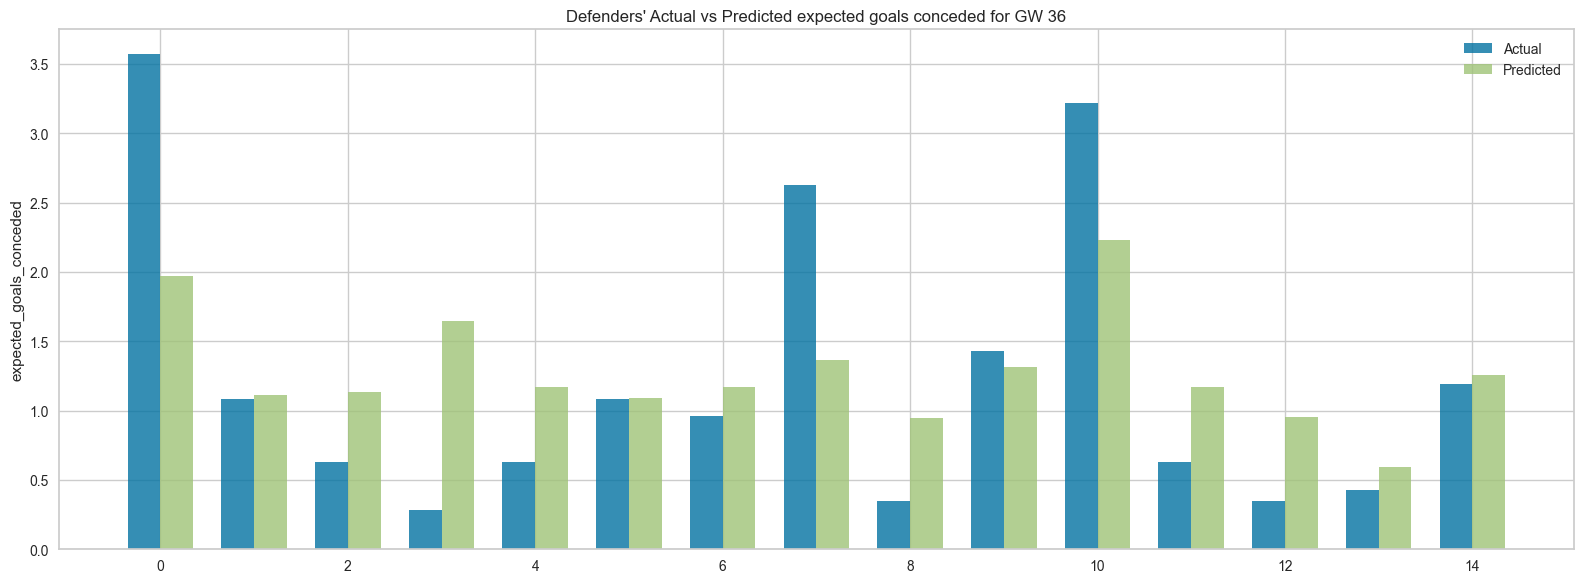

In [626]:
# Bar plot side-by-side

# --- Select 15 random samples ---
n_samples = 15
idx = np.random.choice(len(xgc_def_tar_36), n_samples, replace=False)

actual_sample = xgc_def_tar_36.iloc[idx]
preds_sample = xgc_def_preds_36.iloc[idx]      # dataframe with column 'xgc_preds'


x = np.arange(len(actual_sample))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual_sample, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, preds_sample['xgc_preds'].tolist(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Defenders' Actual vs Predicted expected goals conceded for GW 36")
plt.legend()
plt.tight_layout()
plt.show()

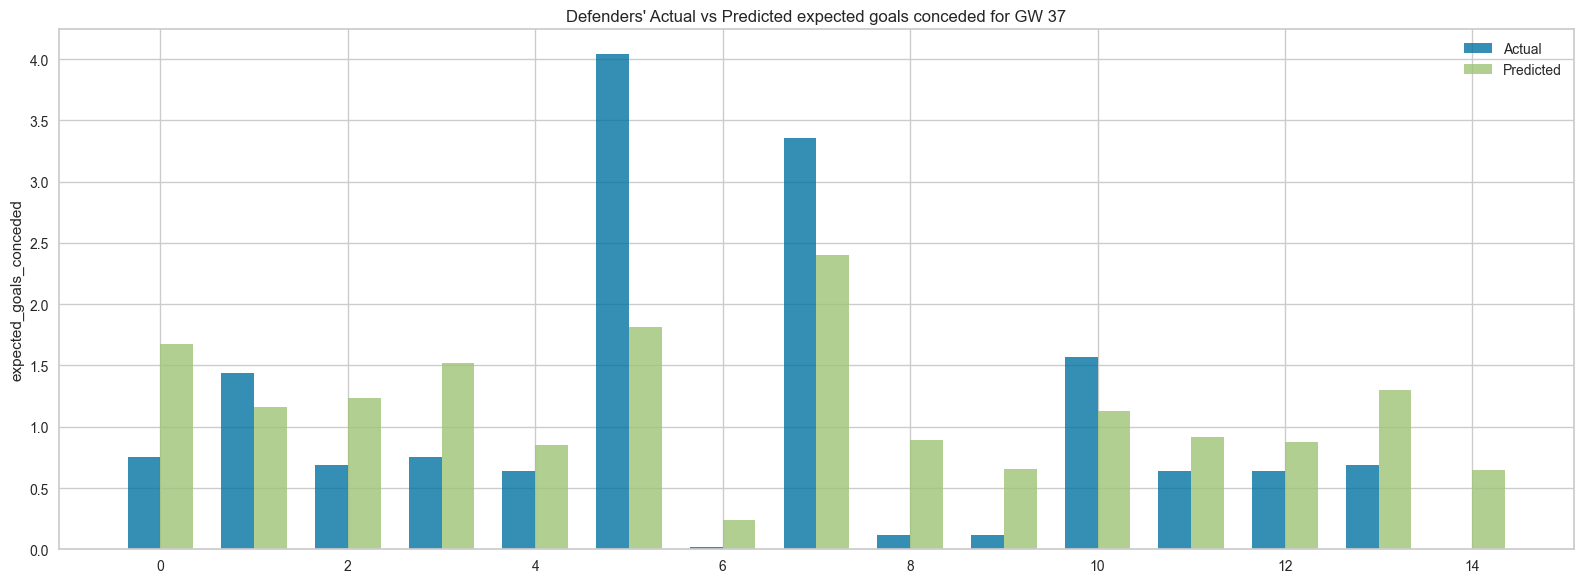

In [627]:
# Bar plot side-by-side

# --- Select 15 random samples ---
n_samples = 15
idx = np.random.choice(len(xgc_def_tar_37), n_samples, replace=False)

actual_sample = xgc_def_tar_37.iloc[idx]
preds_sample = xgc_def_preds_37.iloc[idx]      # dataframe with column 'xgc_preds'


x = np.arange(len(actual_sample))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual_sample, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, preds_sample['xgc_preds'].tolist(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Defenders' Actual vs Predicted expected goals conceded for GW 37")
plt.legend()
plt.tight_layout()
plt.show()

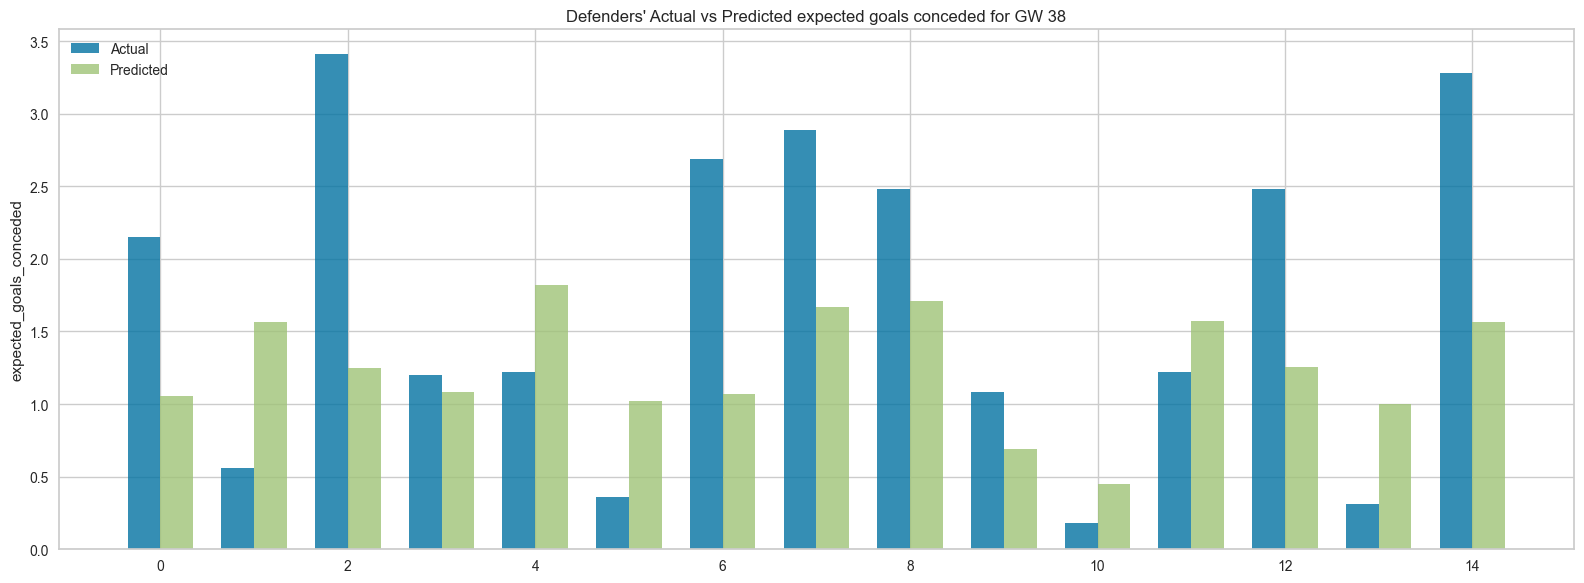

In [628]:
# Bar plot side-by-side

# --- Select 15 random samples ---
n_samples = 15
idx = np.random.choice(len(xgc_def_tar_38), n_samples, replace=False)

actual_sample = xgc_def_tar_38.iloc[idx]
preds_sample = xgc_def_preds_38.iloc[idx]      # dataframe with column 'xgc_preds'


x = np.arange(len(actual_sample))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual_sample, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, preds_sample['xgc_preds'].tolist(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Defenders' Actual vs Predicted expected goals conceded for GW 38")
plt.legend()
plt.tight_layout()
plt.show()

# Combine Gw data predictions


In [629]:
data_36_def.isnull().sum()

assists_x       0
bonus           0
bps             0
clean_sheets    0
creativity      0
               ..
whd             0
wha             0
xG_preds        0
xA_preds        0
xgc_preds       0
Length: 179, dtype: int64

In [630]:
# Merge all the preds and sort by index
preds_36 = pd.concat([data_36_gk, data_36_def, data_36_mid, data_36_fwd]).sort_index()
cols_to_add = ['saves_preds', 'xgc_preds', 'xG_preds', 'xA_preds']

# Now add the columns to the gw_data
data_36[cols_to_add] = preds_36[cols_to_add]
data_36.to_csv('./data_36_with_preds.csv', index=True)

# Merge all the preds and sort by index
preds_37 = pd.concat([data_37_gk, data_37_def, data_37_mid, data_37_fwd]).sort_index()
cols_to_add = ['saves_preds', 'xgc_preds', 'xG_preds', 'xA_preds']

# Now add the columns to the gw_data
data_37[cols_to_add] = preds_37[cols_to_add]
data_37.to_csv('./data_37_with_preds.csv', index=True)

# Merge all the preds and sort by index
preds_38 = pd.concat([data_38_gk, data_38_def, data_38_mid, data_38_fwd]).sort_index()
cols_to_add = ['saves_preds', 'xgc_preds', 'xG_preds', 'xA_preds']

# Now add the columns to the gw_data
data_38[cols_to_add] = preds_38[cols_to_add]
data_38.to_csv('./data_38_with_preds.csv', index=True)